# rug-Contrastive Loss Evaluation

This notebook evaluates a model trained with `train_gat_run_cf_drug_loss.py`.

It:
- Exports predictions on a fixed test split (from meta + test_ids)
- Exports attention (global + drug-grouped)
- Generates evaluation figures
- Runs a drug case study: pick best/worst drug by median sample-wise PCC and compare attention


In [ ]:
import os
import sys
import json
from plot_eval_figures import ExportArgs, export_predictions, generate_test_ids_npy
import importlib
import plot_eval_figures as pef
importlib.reload(pef)
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
ROOT = "/Users/liuxi/Desktop/RFA_GNN"
if not os.path.exists(ROOT):
    ROOT = os.getcwd()
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print("ROOT=", ROOT)
print("SRC =", SRC)


ROOT= /Users/liuxi/Desktop/RFA_GNN
SRC = /Users/liuxi/Desktop/RFA_GNN/src


## Paths


In [48]:
weight_file_name = "weigat_cf_lossghts.h5"
meta_file_name = "gat_cf_loss.meta.json"
npz_file = "gat_cf_loss.eval.npz"


# weight_file_name = "gat_executed.weights.h5"
# meta_file_name = "gat_executed.meta.json"
# npz_file = "gat_executed.eval.npz"

weights_path = os.path.join(ROOT, "saved_models", weight_file_name)
meta_path = os.path.join(ROOT, "saved_models", meta_file_name)
test_ids_path = os.path.splitext(meta_path)[0] + ".test_ids.npy"

out_npz = os.path.join(ROOT, "tmp", npz_file)
out_fig_dir = os.path.join(ROOT, "tmp", npz_file.split(".")[0] + ".fig")

print("weights_path:", weights_path)
print("meta_path   :", meta_path)
print("test_ids    :", test_ids_path)
print("out_npz     :", out_npz)
print("out_fig_dir :", out_fig_dir)


weights_path: /Users/liuxi/Desktop/RFA_GNN/saved_models/weigat_cf_lossghts.h5
meta_path   : /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_cf_loss.meta.json
test_ids    : /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_cf_loss.meta.test_ids.npy
out_npz     : /Users/liuxi/Desktop/RFA_GNN/tmp/gat_cf_loss.eval.npz
out_fig_dir : /Users/liuxi/Desktop/RFA_GNN/tmp/gat_cf_loss.fig


## Export predictions 


In [ ]:

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

meta_test_ids = str(meta.get("test_ids_npy", "")).strip()
if meta_test_ids and os.path.exists(meta_test_ids):
    test_ids_path = meta_test_ids
else:
    test_ids_path = os.path.splitext(meta_path)[0] + ".test_ids.npy"

if not os.path.exists(test_ids_path):
    print("test_ids not found, generating:", test_ids_path)
    generate_test_ids_npy(meta_path=meta_path, out_path=test_ids_path, root=ROOT)
else:
    print("test_ids found:", test_ids_path)

args = ExportArgs(
    root=ROOT,
    weights=weights_path,
    out=out_npz,
    cell_line=meta.get("cell_line", "ALL"),
    use_landmark_genes=bool(meta.get("use_landmark_genes", True)),
    max_samples=0,
    split_mode=meta.get("split_mode", "cold_drug"),
    test_frac=float(meta.get("test_frac", 0.2)),
    sparse_gat=bool(meta.get("sparse_gat", True)),
    use_drug_fp_embedding=bool(meta.get("use_drug_fp_embedding", False)),
    hidden_dim=int(meta.get("hidden_dim", 64)),
    num_heads=int(meta.get("num_heads", 4)),
    dropout=float(meta.get("dropout", 0.2)),
    attention_layers=int(meta.get("attention_layers", 4)),
    per_node_head=bool(meta.get("per_node_head", True)),
    no_cell_embedding=bool(meta.get("no_cell_embedding", False)),
    no_residualize_target_by_cell=bool(meta.get("no_residualize_target_by_cell", False)),
    eval_drug_zero=True,
    eval_drug_shuffle=True,
    eval_sanity_seed=0,
    eval_sanity_max_eval=20000,
    test_ids_npy=test_ids_path,
    export_attention=True,
    attention_max_samples=2000,
    attention_batch_size=64,
    attention_group_by="drug",
    attention_groups="",
    attention_top_k_groups=100,
)

export_predictions(args)
print("Saved:", out_npz)


test_ids found: /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_cf_loss.meta.test_ids.npy
正在加载 RFA 数据 (Landmark Mode: True)...
CSV路径: CTL=/Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_ctl_n188708x12328.h5, TRT=/Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_trt_cp_n1805898x12328.h5
目标基因数: 978
正在读取元数据: /Users/liuxi/Desktop/RFA_GNN/data/siginfo_beta.txt
过滤后元数据记录数: 117284
发现 57929 个 Control 样本，涉及 162 个细胞系。
正在加载所有 Control 数据以计算均值...
正在加载数据文件: /Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_ctl_n188708x12328.h5 ...
  H5 (h5py): 匹配到 57929 个样本 (axis0/Index). 读取中...
  读取耗时: 28.61s
  Gene ID 匹配: Index=0, Columns=978
  形状检查: Rows=57929, Target=978
  已筛选并对齐到 978 个 Genes。
发现 67663 个高质量 Treatment 样本。
正在加载 Treatment 数据...
正在加载数据文件: /Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_trt_cp_n1805898x12328.h5 ...
  H5 (h5py): 匹配到 67663 个样本 (axis0/Index). 读取中...


KeyboardInterrupt: 

## Generate figures


In [ ]:


os.makedirs(out_fig_dir, exist_ok=True)
run = pef.load_eval_npz(out_npz)
tag = os.path.splitext(os.path.basename(out_npz))[0]
print("tag=", tag)


tag= gat_cf_loss.eval


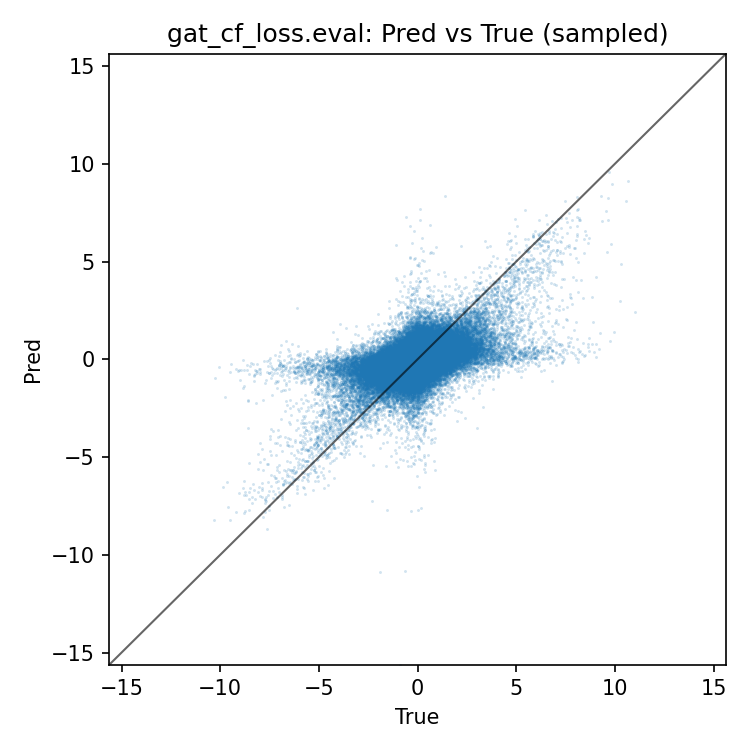

In [ ]:
pef.plot_true_pred_scatter(run, out_path=os.path.join(out_fig_dir, f"{tag}_scatter_all.png"))
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_scatter_all.png")))


top_cells: ['PC3', 'MCF7', 'VCAP', 'A549', 'HA1E', 'MCF10A', 'A375', 'HCC515', 'HT29', 'NPC']


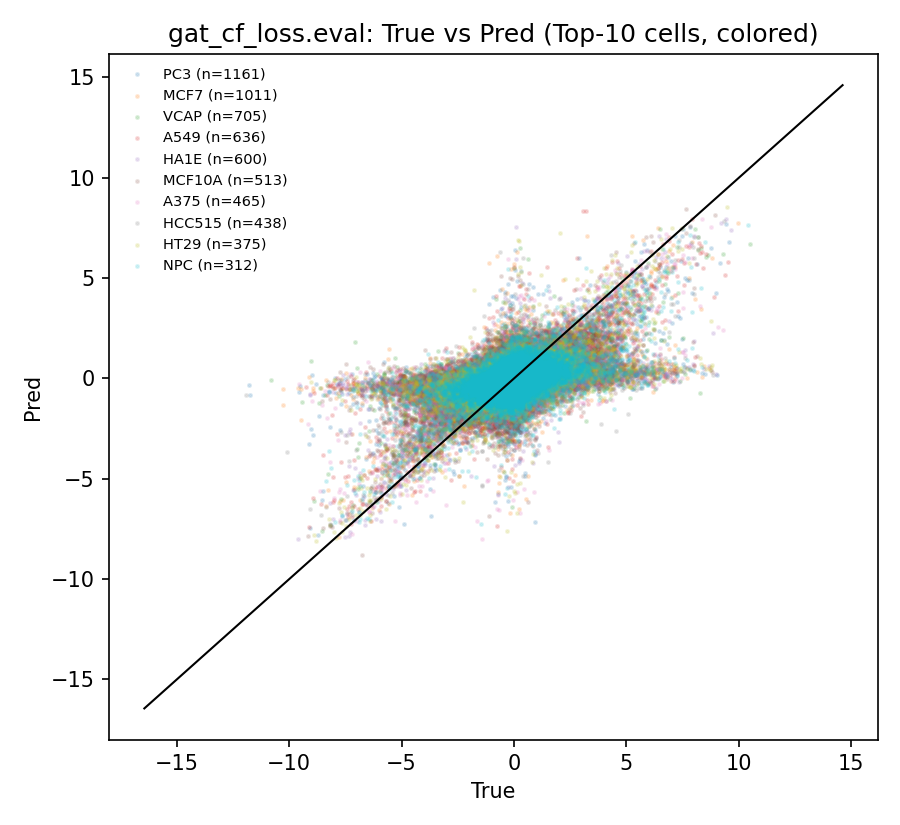

In [ ]:


cell_names = np.asarray(run["cell_names"], dtype=str)
uniq, counts = np.unique(cell_names, return_counts=True)
top_cells = uniq[np.argsort(-counts)][:10]
print("top_cells:", top_cells.tolist())

y_true = np.asarray(run["y_true"], dtype=np.float32)
y_pred = np.asarray(run["y_pred"], dtype=np.float32)

rng = np.random.default_rng(0)
max_points_per_cell = 30000
max_samples_per_cell = 200

plt.figure(figsize=(6.0, 5.5), dpi=150)
colors = plt.cm.tab10(np.linspace(0, 1, len(top_cells)))
for i, c in enumerate(top_cells):
    m = cell_names == str(c)
    idx = np.where(m)[0]
    if len(idx) == 0:
        continue
    if len(idx) > max_samples_per_cell:
        idx = rng.choice(idx, size=max_samples_per_cell, replace=False)
    yt = y_true[idx].reshape(-1)
    yp = y_pred[idx].reshape(-1)
    if len(yt) > max_points_per_cell:
        sel = rng.choice(len(yt), size=max_points_per_cell, replace=False)
        yt = yt[sel]
        yp = yp[sel]
    plt.scatter(yt, yp, s=2, alpha=0.15, color=colors[i], label=f"{c} (n={int(np.sum(m))})")

mn = float(min(np.min(y_true), np.min(y_pred)))
mx = float(max(np.max(y_true), np.max(y_pred)))
plt.plot([mn, mx], [mn, mx], color="black", linewidth=1)
plt.xlabel("True")
plt.ylabel("Pred")
plt.title(f"{tag}: True vs Pred (Top-10 cells, colored)")
plt.legend(fontsize=7, frameon=False, loc="best")
plt.tight_layout()

out_path = os.path.join(out_fig_dir, f"{tag}_scatter_cells_top10.png")
plt.savefig(out_path)
plt.close()
display(Image(filename=out_path))


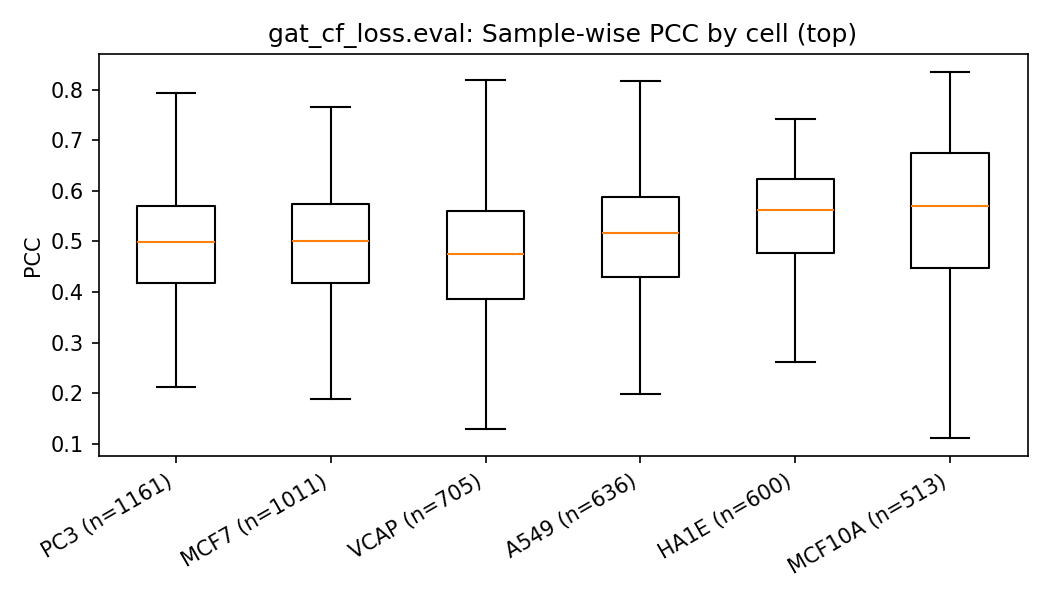

In [ ]:
pef.plot_sample_pcc_by_cell(run, out_path=os.path.join(out_fig_dir, f"{tag}_pcc_by_cell.png"), top_k=6)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_pcc_by_cell.png")))


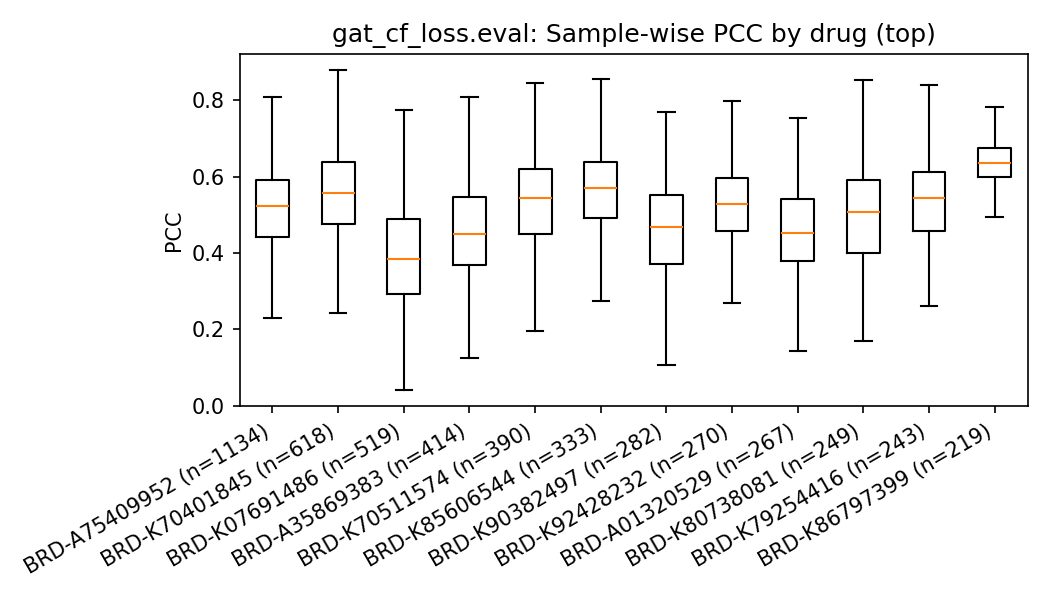

In [ ]:
pef.plot_sample_pcc_by_drug(run, out_path=os.path.join(out_fig_dir, f"{tag}_pcc_by_drug.png"), top_k=12)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_pcc_by_drug.png")))


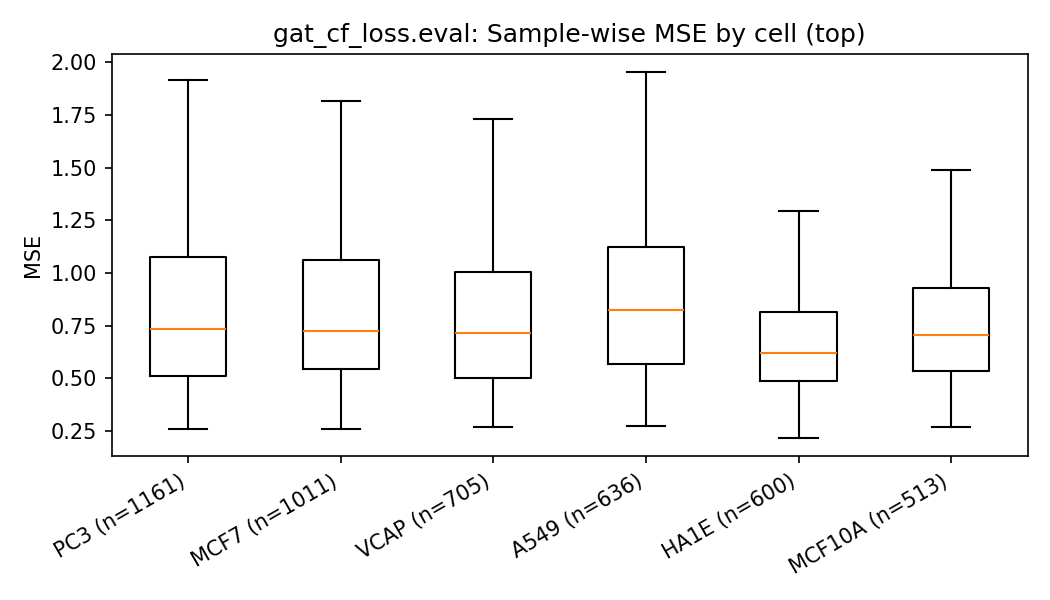

In [ ]:
pef.plot_sample_mse_by_cell(run, out_path=os.path.join(out_fig_dir, f"{tag}_mse_by_cell.png"), top_k=6)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_mse_by_cell.png")))


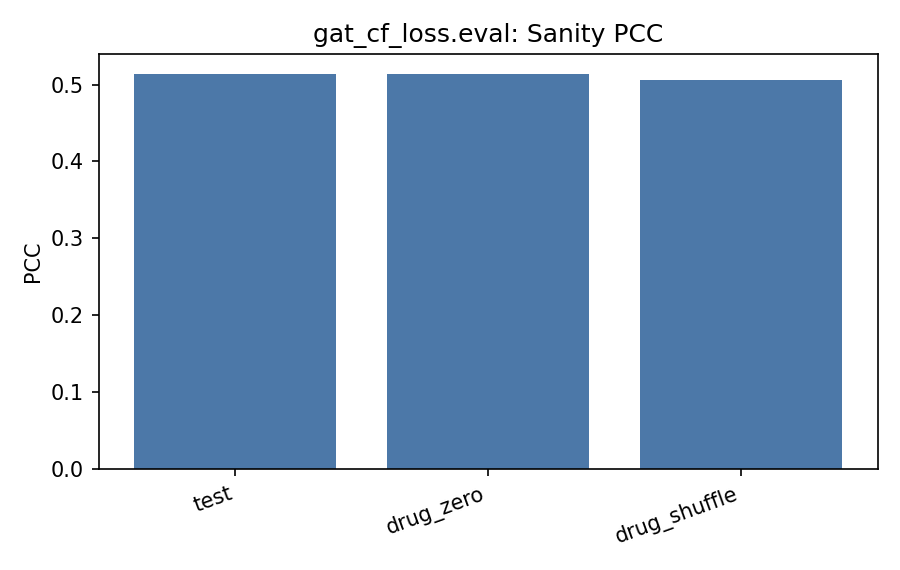

In [ ]:
pef.plot_sanity_pcc(run, out_path=os.path.join(out_fig_dir, f"{tag}_sanity_pcc.png"))
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_sanity_pcc.png")))


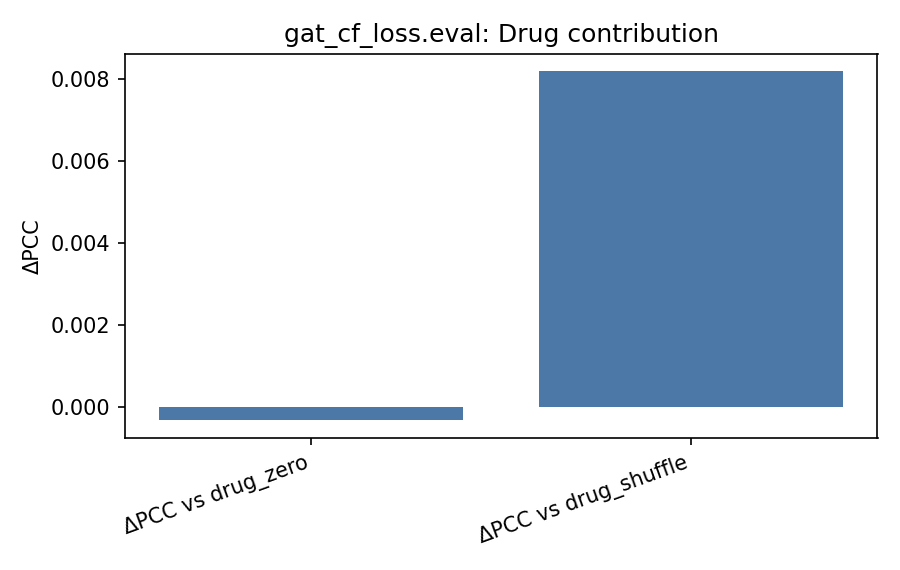

In [ ]:
pef.plot_delta_pcc(run, out_path=os.path.join(out_fig_dir, f"{tag}_delta_pcc.png"))
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_delta_pcc.png")))


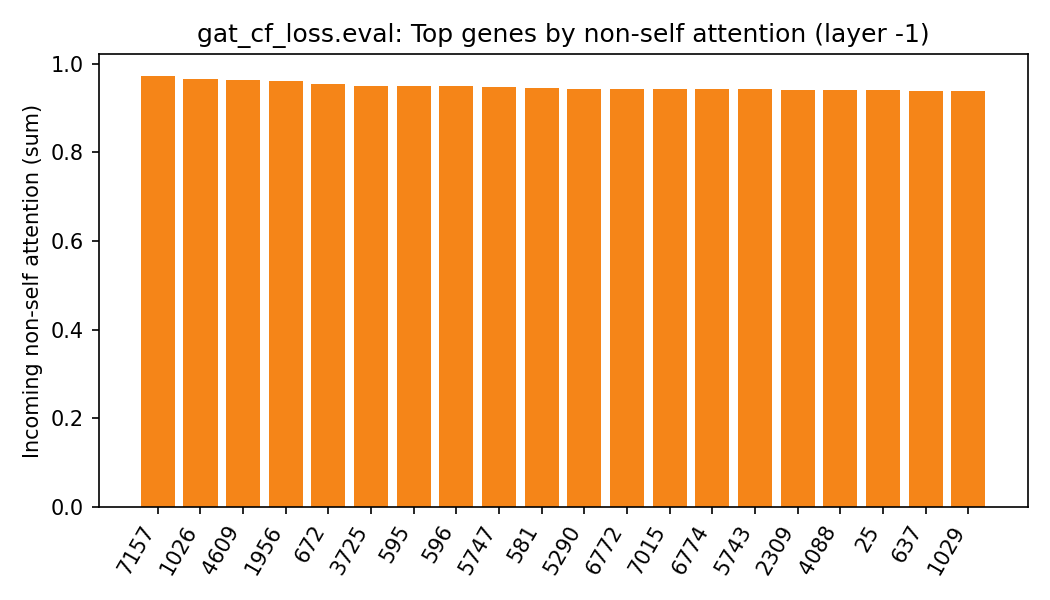

In [ ]:
p_attn = os.path.join(out_fig_dir, f"{tag}_attn_top_genes.png")
pef.plot_attention_top_genes(run, out_path=p_attn, top_k=20, layer=-1)
display(Image(filename=p_attn))


In [ ]:
df_edges = pef.export_attention_top_edges_csv(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_attn_top_edges.csv"),
    top_k=50,
    layer=-1,
)
df_edges.head(15)


,src_idx,dst_idx,src_gene,dst_gene,attention
0,839,596,3091,55818,0.682038
1,262,547,1870,8726,0.680542
2,839,481,3091,226,0.670783
3,839,961,3091,4891,0.670356
4,644,387,5111,57804,0.657581
5,839,611,3091,664,0.647274
6,16,773,1050,51170,0.640557
7,839,594,3091,6275,0.635090
8,124,679,2624,7867,0.618308
9,524,214,355,1616,0.617597


In [ ]:
import pandas as pd

gene_info_path = os.path.join(ROOT, "data", "GSE92742_Broad_LINCS_gene_info.txt")
gi = pd.read_csv(gene_info_path, sep="\t")
entrez2symbol = dict(zip(gi["pr_gene_id"].astype(str), gi["pr_gene_symbol"].astype(str)))

df_edges["src_symbol"] = df_edges["src_gene"].astype(str).map(entrez2symbol)
df_edges["dst_symbol"] = df_edges["dst_gene"].astype(str).map(entrez2symbol)

df_edges[["src_symbol", "dst_symbol", "attention"]].head(15)


,src_symbol,dst_symbol,attention
0,HIF1A,KDM3A,0.682038
1,E2F2,EED,0.680542
2,HIF1A,ALDOA,0.670783
3,HIF1A,SLC11A2,0.670356
4,PCNA,POLD4,0.657581
5,HIF1A,BNIP3,0.647274
6,CEBPA,HSD17B11,0.640557
7,HIF1A,S100A4,0.635090
8,GATA2,MAPKAPK3,0.618308
9,FAS,DAXX,0.617597


## UMAP (PCA(40) → UMAP(k=15))


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import umap

y_true_all = np.asarray(run["y_true"], dtype=np.float32)
y_pred_all = np.asarray(run["y_pred"], dtype=np.float32)
resid_all = y_pred_all - y_true_all

cell_all = np.asarray(run.get("cell_names", []), dtype=str)
drug_all = np.asarray(run.get("drug_ids", []), dtype=str)
plate_all = np.asarray(run.get("det_plate_ids", []), dtype=str)
batch_all = np.asarray(run.get("batch_ids", []), dtype=str)

n = int(y_true_all.shape[0])
rng = np.random.default_rng(0)
max_umap_samples = 8000
idx = np.arange(n)
if n > max_umap_samples:
    idx = rng.choice(n, size=max_umap_samples, replace=False)
idx = np.sort(idx)

def _pca_umap(X, random_state=0):
    X = np.asarray(X, dtype=np.float32)
    Xp = PCA(n_components=40, random_state=random_state).fit_transform(X)
    emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=random_state).fit_transform(Xp)
    return emb

umap_true = _pca_umap(y_true_all[idx], random_state=0)
umap_pred = _pca_umap(y_pred_all[idx], random_state=1)
umap_resid = _pca_umap(resid_all[idx], random_state=2)

cell = cell_all[idx] if cell_all.size else None
drug = drug_all[idx] if drug_all.size else None
plate = plate_all[idx] if plate_all.size else None
batch = batch_all[idx] if batch_all.size else None

print("UMAP samples:", len(idx))


/opt/anaconda3/envs/RFA_GNN/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/opt/anaconda3/envs/RFA_GNN/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/RFA_GNN/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP samples: 8000


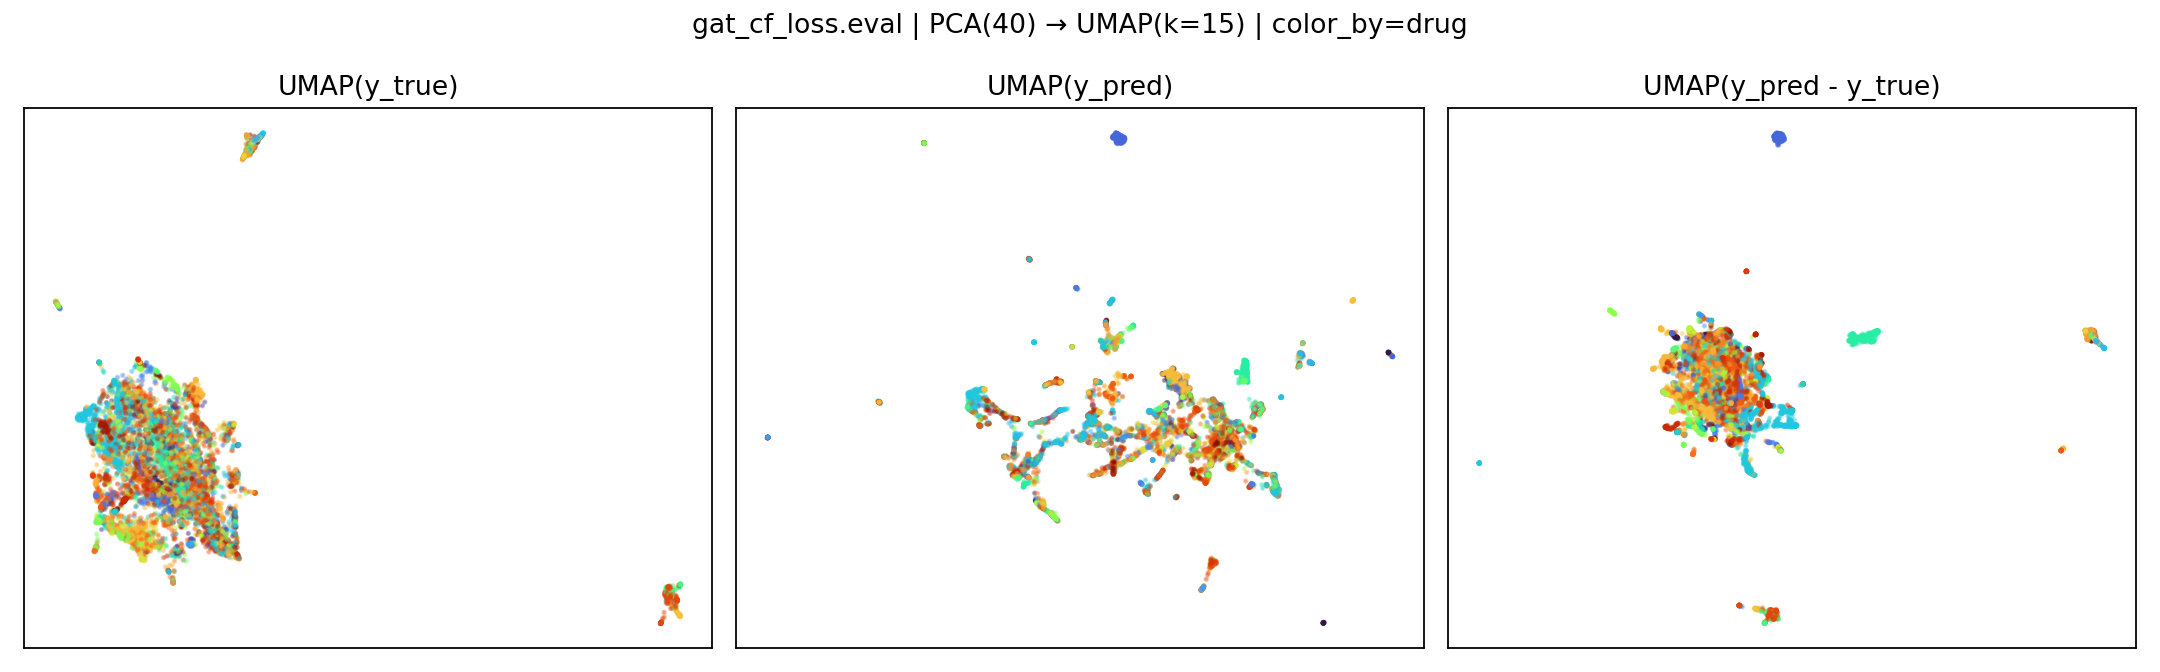

In [51]:

color_by = "drug"
top_k_cell = 12
top_k_drug = 100

def _topk_map(labels, top_k):
    labels = np.asarray(labels, dtype=str)
    uniq, cnt = np.unique(labels, return_counts=True)
    order = uniq[np.argsort(-cnt)]
    keep = set(order[: int(top_k)].tolist())
    out = np.array([x if x in keep else "Other" for x in labels], dtype=str)
    return out

def _plot(ax, emb, labels, title):
    if labels is None or len(labels) == 0:
        ax.scatter(emb[:, 0], emb[:, 1], s=2, alpha=0.35)
        ax.set_title(title)
        return

    labels2 = labels
    legend = False
    if color_by == "cell":
        labels2 = _topk_map(labels, top_k=top_k_cell)
        legend = True
    elif color_by == "drug":
        labels2 = _topk_map(labels, top_k=top_k_drug)
        legend = False

    uniq = np.unique(labels2)
    if legend:
        cmap = plt.cm.tab20(np.linspace(0, 1, len(uniq)))
        for i, u in enumerate(uniq):
            m = labels2 == u
            ax.scatter(emb[m, 0], emb[m, 1], s=3, alpha=0.35, color=cmap[i], label=f"{u} (n={int(np.sum(m))})")
        ax.legend(fontsize=7, frameon=False, loc="best")
    else:
        codes = np.unique(labels2, return_inverse=True)[1]
        ax.scatter(emb[:, 0], emb[:, 1], s=2, alpha=0.35, c=codes, cmap="turbo")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

labels = None
if color_by == "cell":
    labels = cell
elif color_by == "drug":
    labels = drug
elif color_by == "plate":
    labels = plate
elif color_by == "batch":
    labels = batch

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), dpi=160)
_plot(axes[0], umap_true, labels, "UMAP(y_true)")
_plot(axes[1], umap_pred, labels, "UMAP(y_pred)")
_plot(axes[2], umap_resid, labels, "UMAP(y_pred - y_true)")
plt.suptitle(f"{tag} | PCA(40) → UMAP(k=15) | color_by={color_by}")
plt.tight_layout()

out_path = os.path.join(out_fig_dir, f"{tag}_umap_{color_by}.png")
plt.savefig(out_path)
plt.close()
display(Image(filename=out_path))


## Case study (drug-specific attention)


In [ ]:
import numpy as np
import pandas as pd

att = run.get("attention", {})
groups = att.get("group_attention_edge_mean", {})
if not isinstance(groups, dict) or len(groups) == 0:
    raise ValueError("No group attention found. Re-run export with attention_group_by=\"drug\".")

drug_ids = np.asarray(run["drug_ids"], dtype=str)
pcc = np.asarray(run["sample_pcc"], dtype=float)

rows = []
for d in sorted(groups.keys()):
    m = drug_ids == str(d)
    if int(np.sum(m)) == 0:
        continue
    vals = pcc[m]
    rows.append({"drug": str(d), "n": int(len(vals)), "pcc_median": float(np.median(vals)), "pcc_mean": float(np.mean(vals))})

df_drug = pd.DataFrame(rows).sort_values(["pcc_median", "n"], ascending=[False, False]).reset_index(drop=True)
display(df_drug)

best_drug = df_drug.iloc[0]["drug"]
worst_drug = df_drug.iloc[-1]["drug"]
print("best_drug =", best_drug)
print("worst_drug=", worst_drug)


,drug,n,pcc_median,pcc_mean
0,BRD-K12867552,93,0.657534,0.640748
1,BRD-K99260425,27,0.639412,0.635227
2,BRD-K86797399,219,0.635469,0.640127
3,BRD-A58767537,87,0.634493,0.629881
4,BRD-A15415227,15,0.610703,0.602922
...,...,...,...,...
95,BRD-K98763141,9,0.375961,0.395829
96,BRD-K08807999,9,0.350768,0.343374
97,BRD-K61665160,27,0.343767,0.350183
98,BRD-K54006094,51,0.340140,0.379440


best_drug = BRD-K12867552
worst_drug= BRD-A07780951


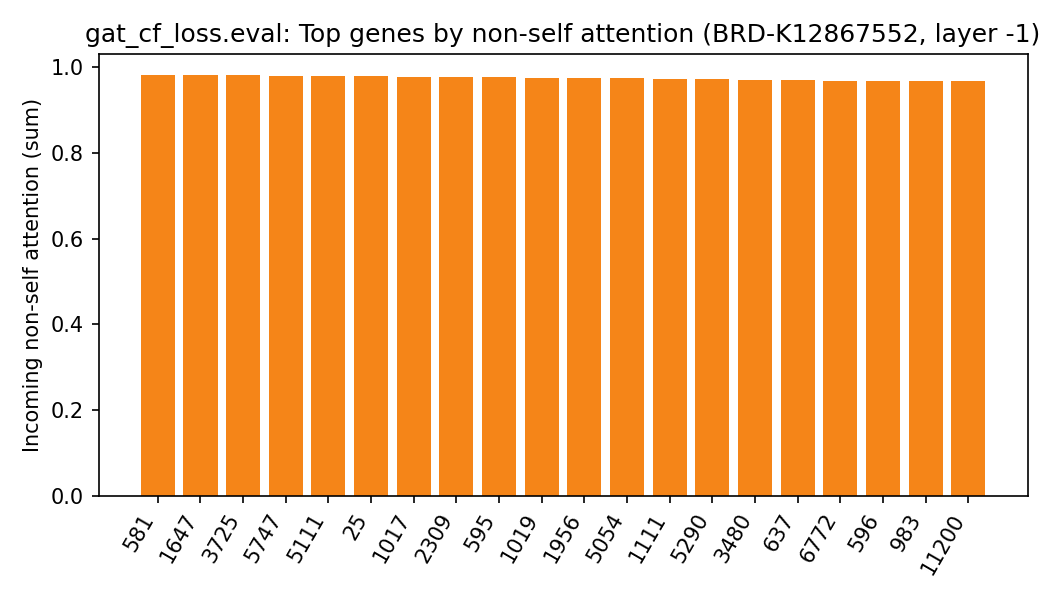

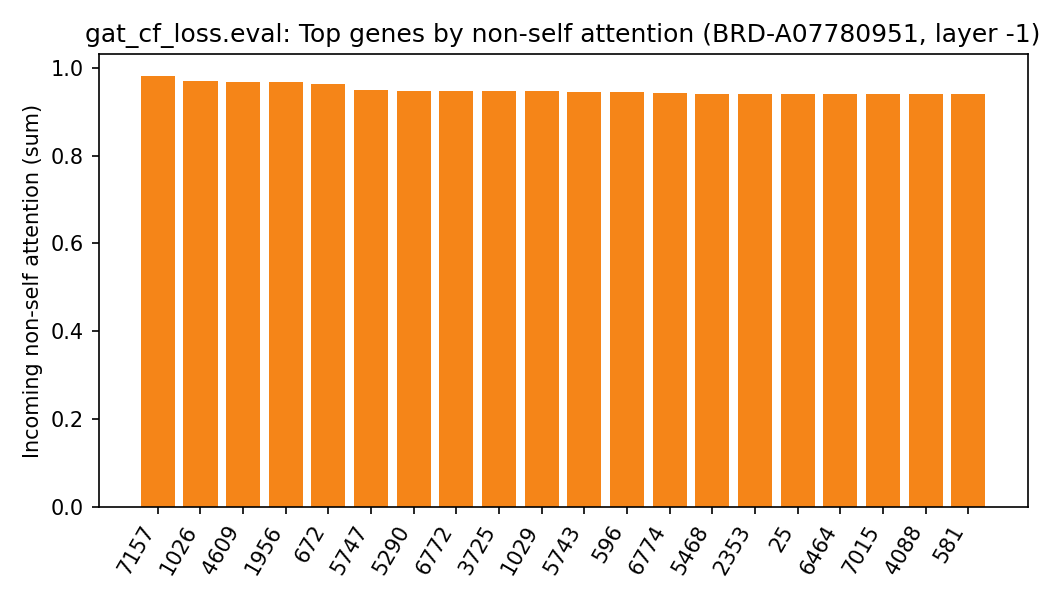

In [ ]:
p_best = os.path.join(out_fig_dir, f"{tag}_attn_top_genes_best.png")
p_worst = os.path.join(out_fig_dir, f"{tag}_attn_top_genes_worst.png")

pef.plot_attention_top_genes(run, out_path=p_best, top_k=20, layer=-1, group=best_drug)
pef.plot_attention_top_genes(run, out_path=p_worst, top_k=20, layer=-1, group=worst_drug)

display(Image(filename=p_best))
display(Image(filename=p_worst))


In [ ]:
pd.set_option('display.max_rows', 200)

df_best = pef.export_attention_top_edges_csv(run, out_path=os.path.join(out_fig_dir, f"{tag}_attn_top_edges_best.csv"), top_k=100, layer=-1, group=best_drug)
df_worst = pef.export_attention_top_edges_csv(run, out_path=os.path.join(out_fig_dir, f"{tag}_attn_top_edges_worst.csv"), top_k=100, layer=-1, group=worst_drug)

def with_symbol(df):
    df = df.copy()
    df["src_symbol"] = df["src_gene"].astype(str).map(entrez2symbol)
    df["dst_symbol"] = df["dst_gene"].astype(str).map(entrez2symbol)
    return df

print("\n--- best drug:", best_drug, "---")
display(with_symbol(df_best)[["src_symbol", "dst_symbol", "attention"]].head(100))




--- best drug: BRD-K12867552 ---


,src_symbol,dst_symbol,attention
0,MYC,FAH,0.884532
1,MYC,HERPUD1,0.881326
2,MYC,ZNF451,0.878820
3,MYC,FUT1,0.878000
4,MYC,FPGS,0.876484
5,MYC,PAICS,0.874814
6,MYC,RFC2,0.873371
7,MYC,NIT1,0.870705
8,MYC,DCK,0.864221
9,MYC,POLG2,0.863849


In [ ]:
print("\n--- worst drug:", worst_drug, "---")
display(with_symbol(df_worst)[["src_symbol", "dst_symbol", "attention"]].head(100))

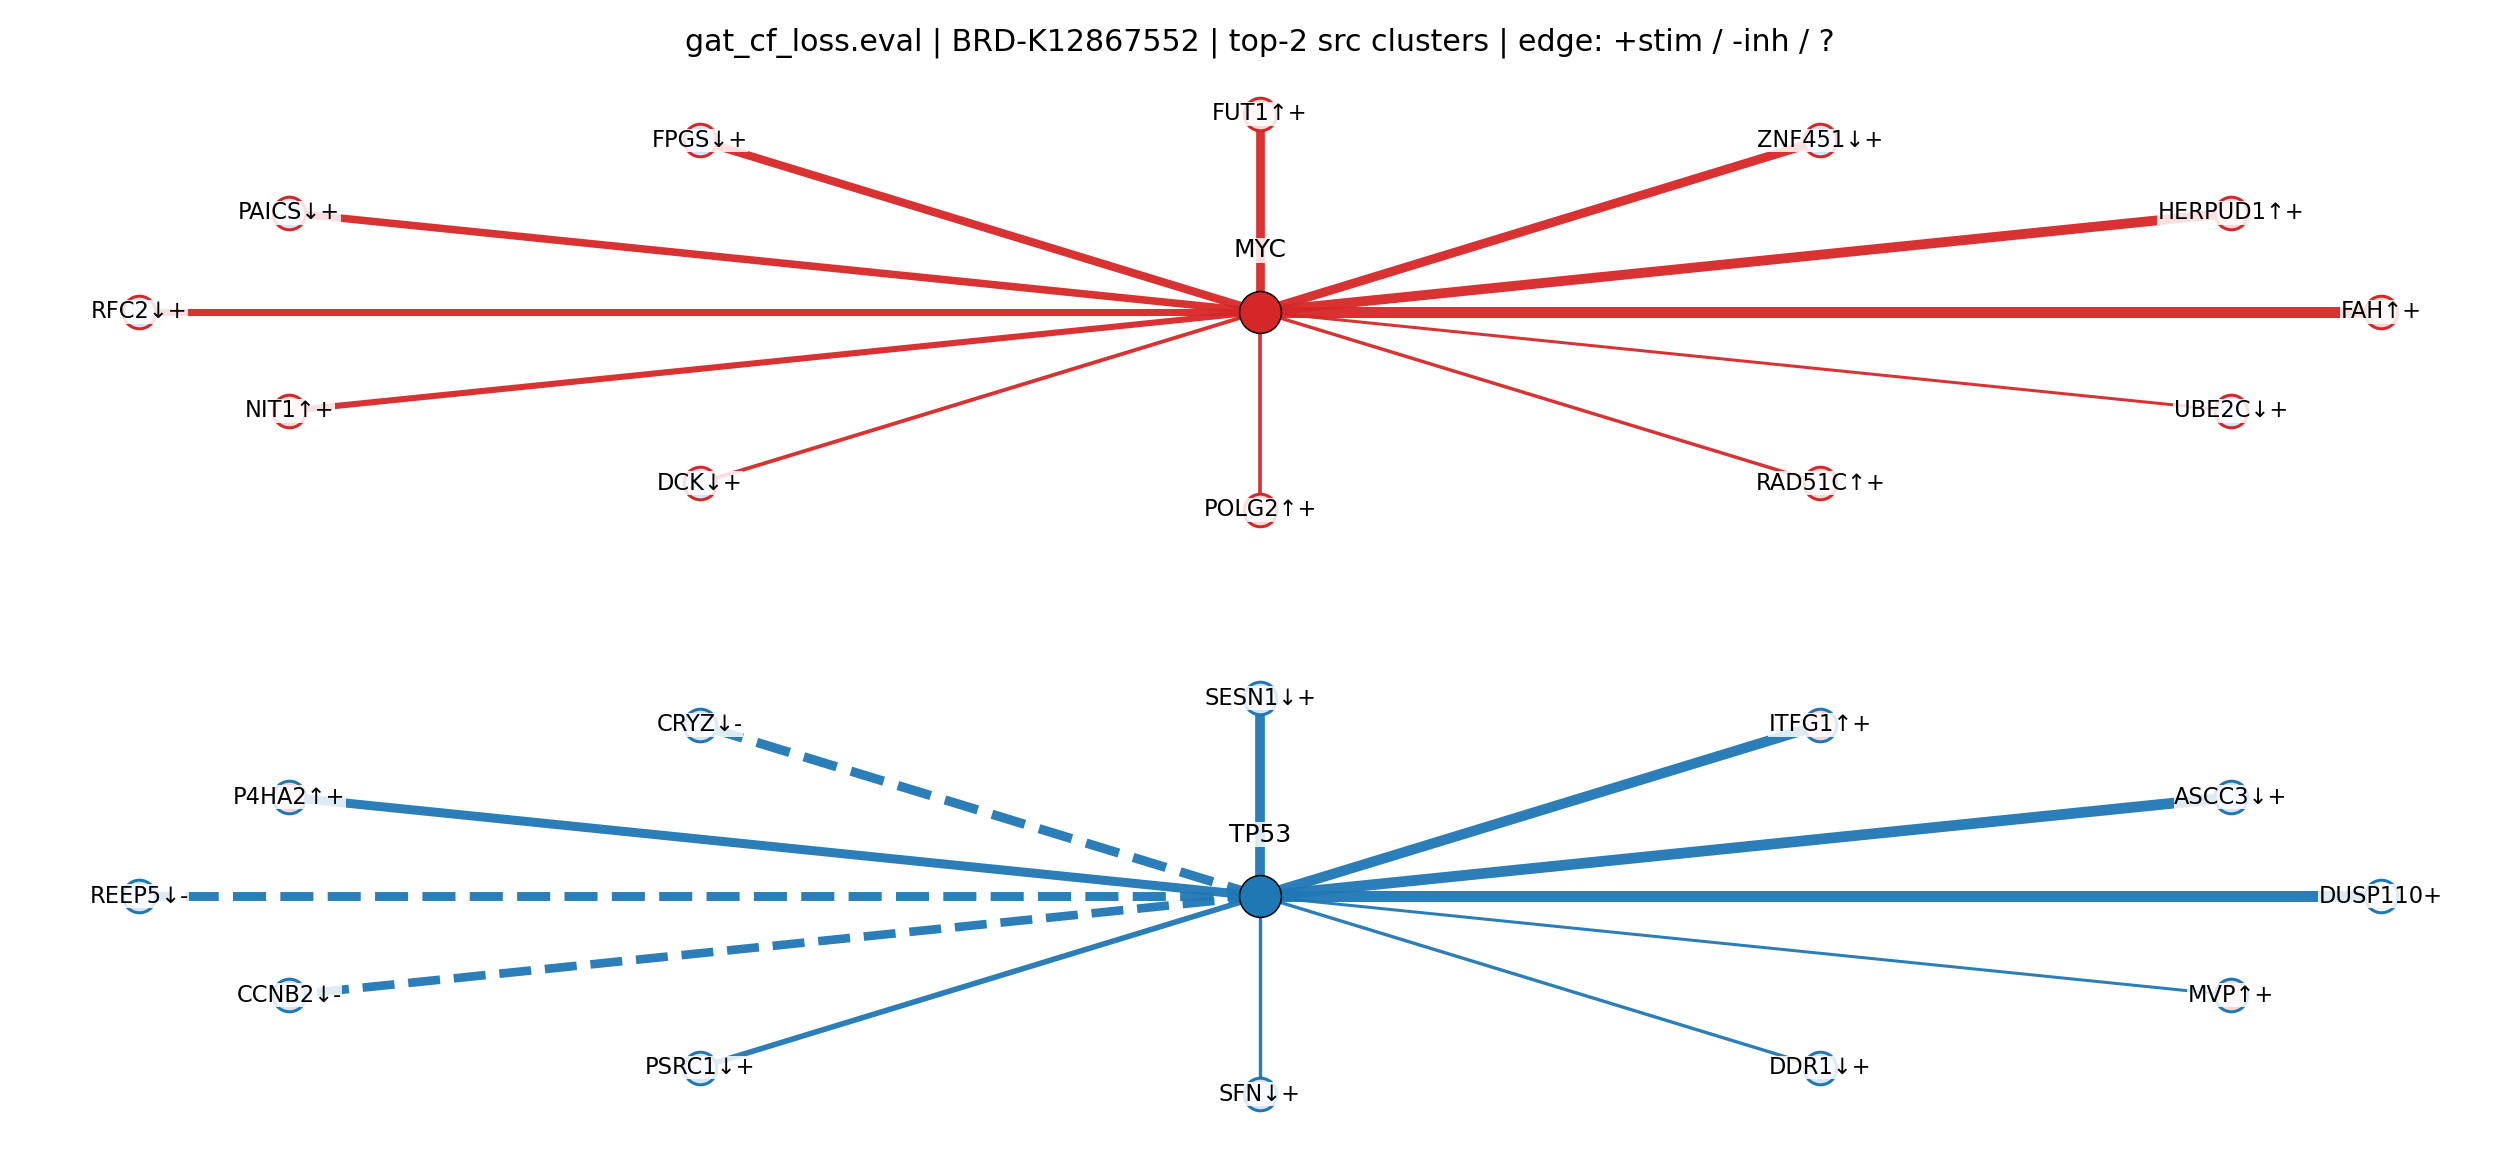

drug= BRD-K12867552 targets= ['HDAC6', 'HDAC2']
PATH_SOURCE=fallback_train_graph target= HDAC6 root= MYC path= ['HDAC6', 'ELAVL1', 'MYC']
PATH_SOURCE=fallback_train_graph target= HDAC6 root= TP53 path= ['HDAC6', 'ELAVL1', 'TP53']


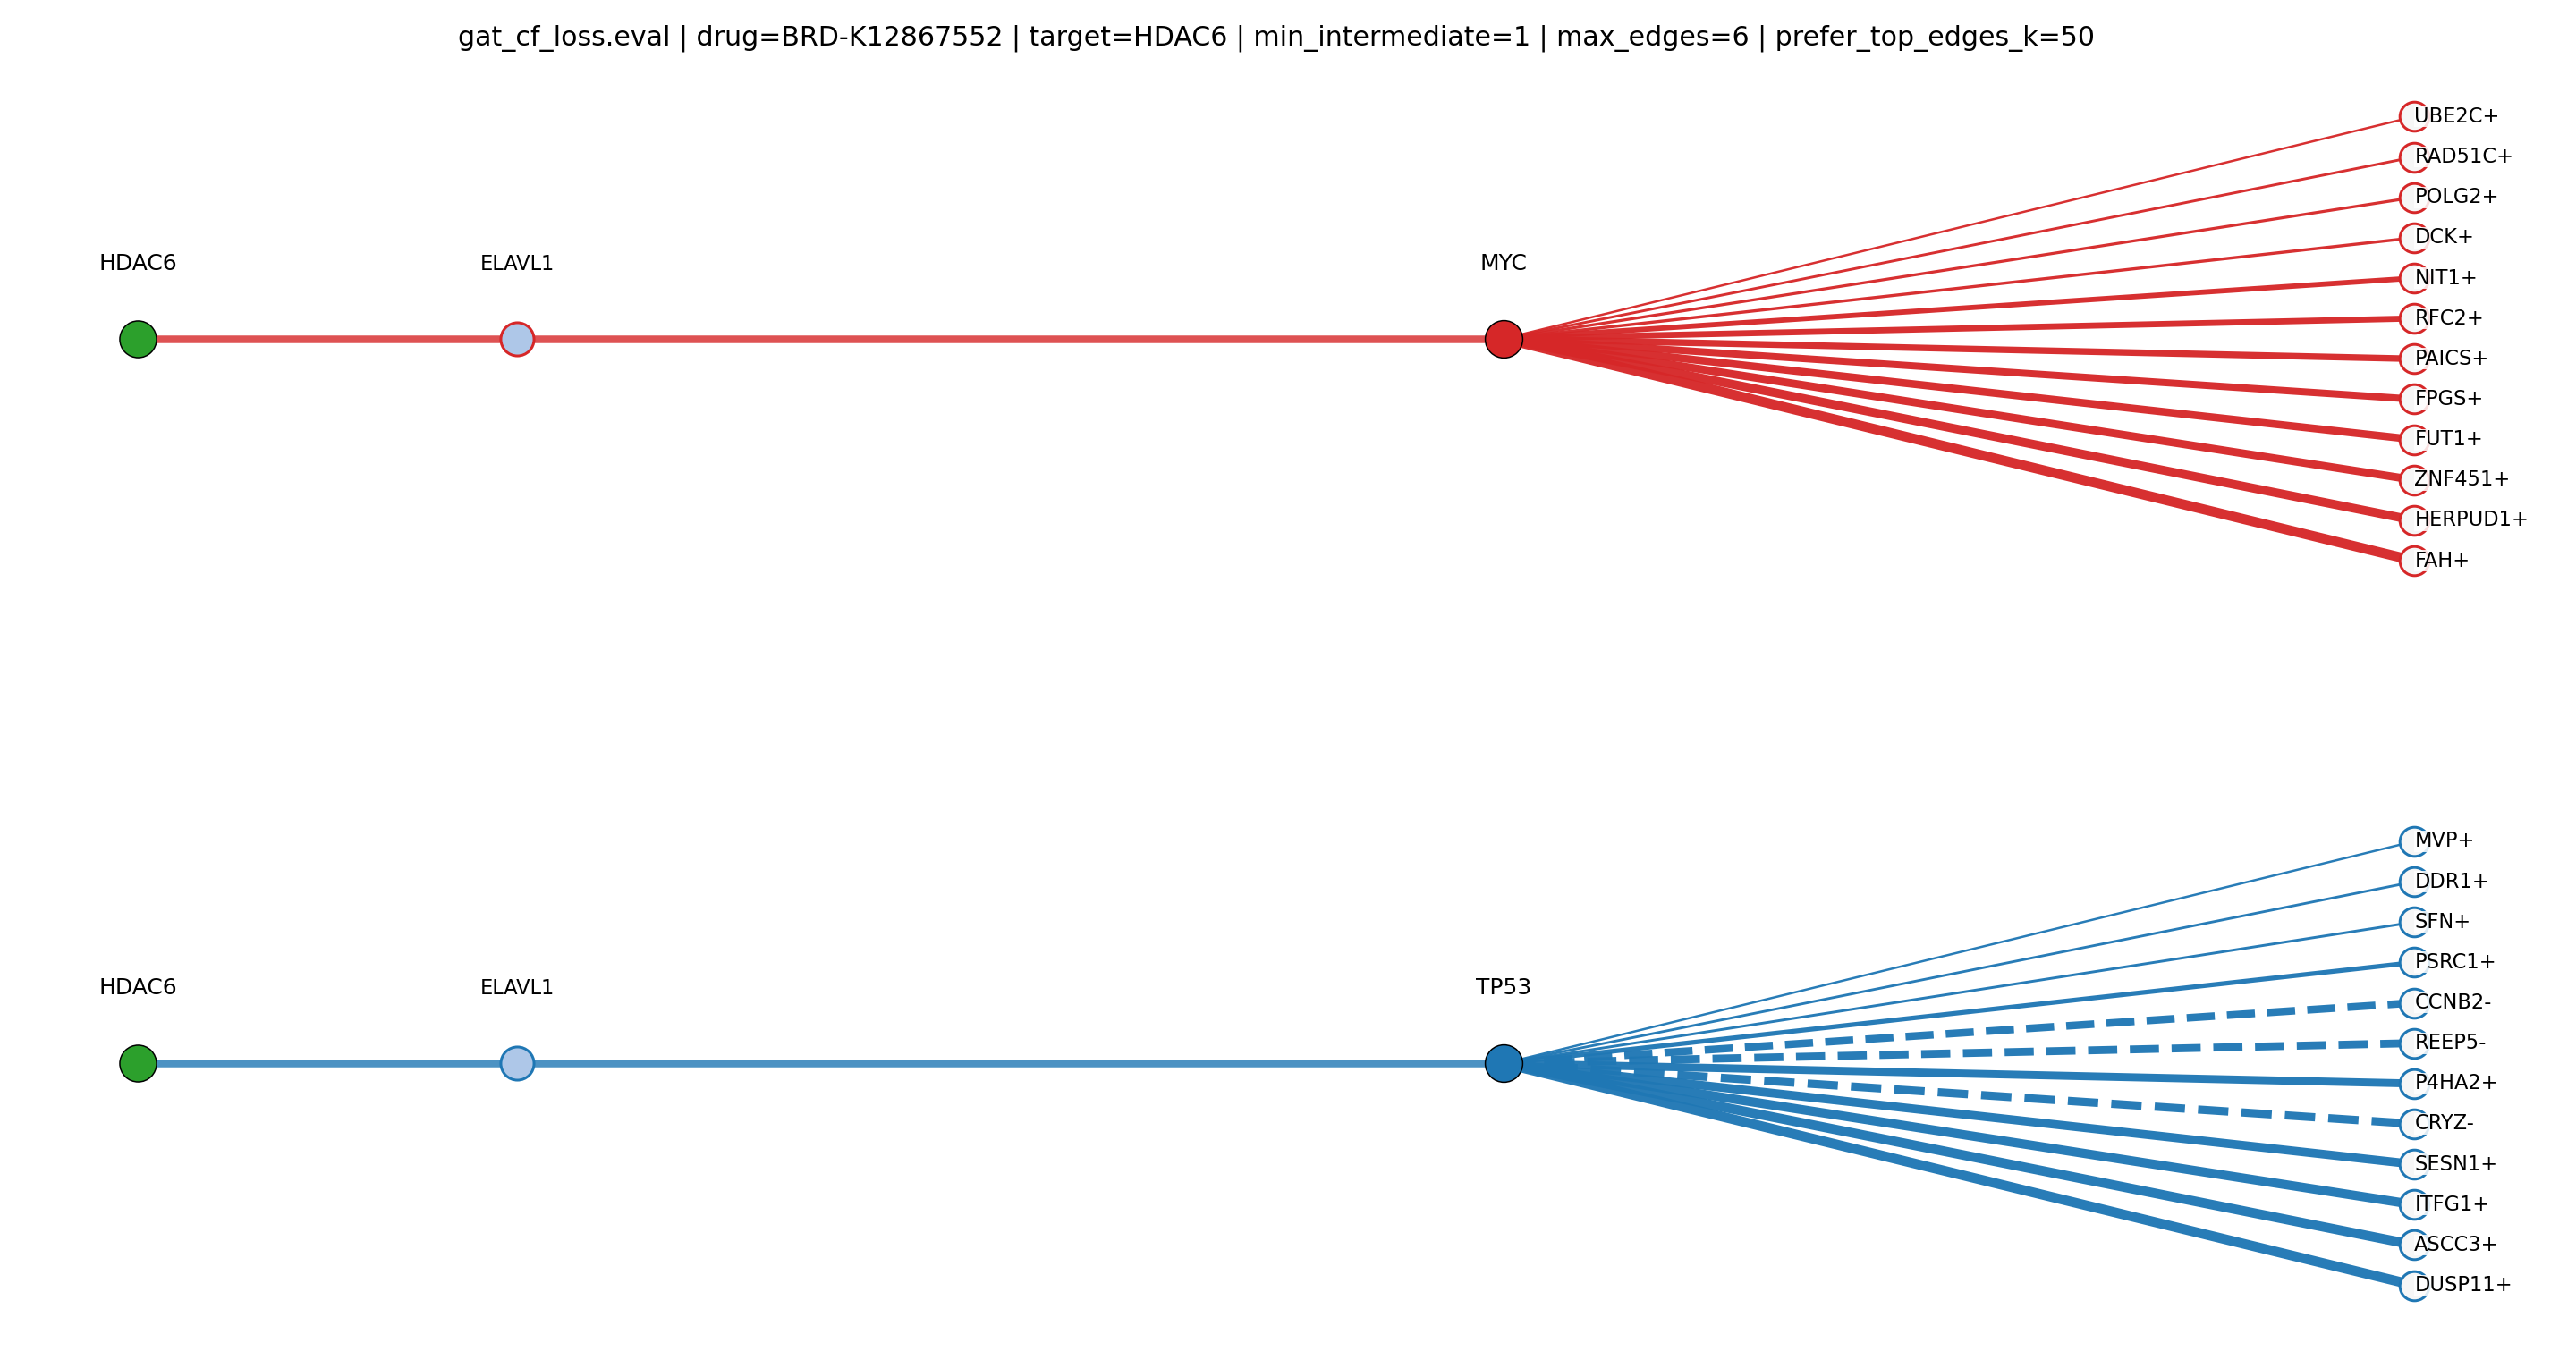

PATH_SOURCE=fallback_train_graph target= HDAC2 root= MYC path= ['HDAC2', 'STAT3', 'MYC']
PATH_SOURCE=fallback_train_graph target= HDAC2 root= TP53 path= ['HDAC2', 'DNMT1', 'TP53']


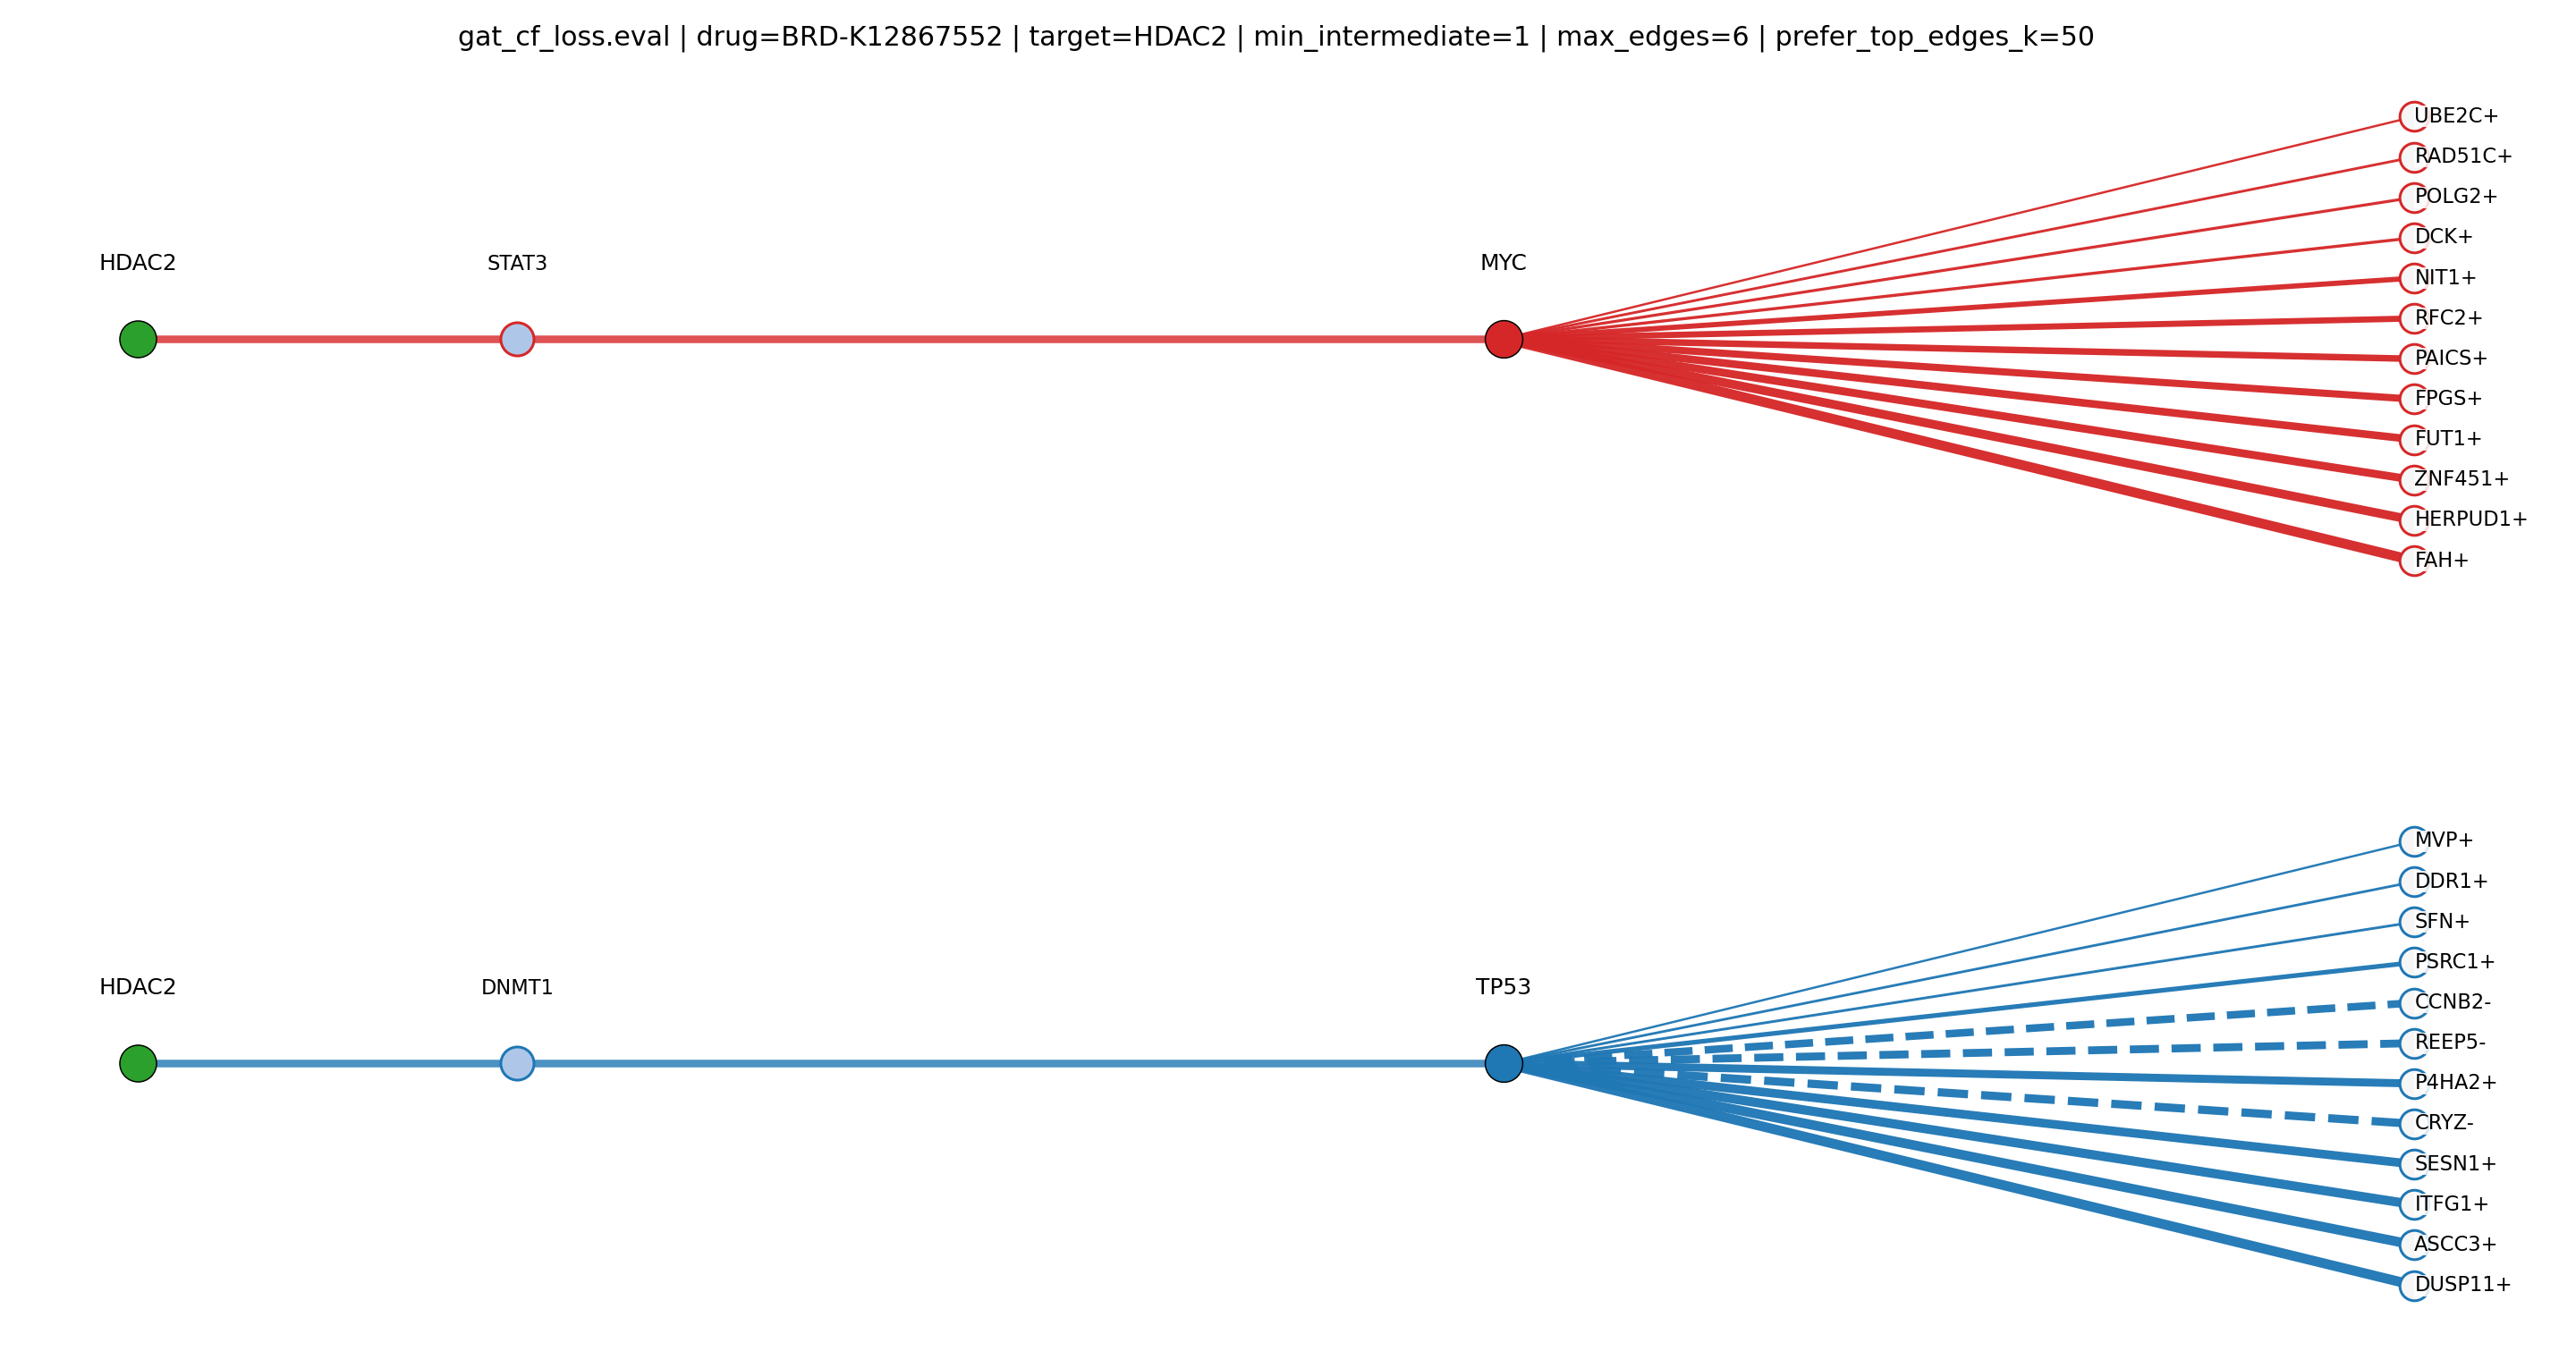

[{'src_idx': 896,
  'src_label': 'MYC',
  'df':     src_idx  dst_idx src_gene dst_gene  attention
  0       896      947     4609     2184   0.884532
  1       896      444     4609     9709   0.881326
  2       896      753     4609    26036   0.878820
  3       896       86     4609     2523   0.878000
  4       896       14     4609     2356   0.876484
  5       896      276     4609    10606   0.874814
  6       896      905     4609     5982   0.873371
  7       896      951     4609     4817   0.870705
  8       896      221     4609     1633   0.864221
  9       896       58     4609    11232   0.863849
  10      896      881     4609     5889   0.863064
  11      896       20     4609    11065   0.861894
  12      896      678     4609     7866   0.858413
  13      896      521     4609     8624   0.857731
  14      896       96     4609     1282   0.848008
  15      896      913     4609     5997   0.833948
  18      896       44     4609    23077   0.821839
  25      896     

In [ ]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display

cluster_k = 2
top_k_per_cluster = 12
hop_limit = 6
use_directed_paths = True

edge_index = np.asarray(run["attention"]["edge_index"], dtype=int)
G_dir = nx.DiGraph()
G_dir.add_nodes_from(range(int(np.max(edge_index)) + 1))
G_dir.add_edges_from(list(zip(edge_index[0].tolist(), edge_index[1].tolist())))
G_und = G_dir.to_undirected(as_view=False)
G_path = G_dir

genes = np.asarray(run.get("target_genes"), dtype=str)
entrez_to_idx = {str(g): int(i) for i, g in enumerate(genes.tolist())}

gene_info_path = os.path.join(ROOT, "data", "GSE92742_Broad_LINCS_gene_info.txt")
gi = pd.read_csv(gene_info_path, sep="\t")
entrez2symbol = dict(zip(gi["pr_gene_id"].astype(str), gi["pr_gene_symbol"].astype(str)))
symbol2entrez = dict(zip(gi["pr_gene_symbol"].astype(str), gi["pr_gene_id"].astype(str)))

compound_targets_path = os.path.join(ROOT, "data", "compound_targets.txt")
df_targets = pd.read_csv(compound_targets_path, sep="\t", dtype=str)

tf_edges_path = os.path.join(ROOT, "data", "omnipath", "omnipath_tf_regulons.csv")
ppi_edges_path = os.path.join(ROOT, "data", "omnipath", "omnipath_interactions.csv")
df_tf_edges = pd.read_csv(tf_edges_path)
df_ppi_edges = pd.read_csv(ppi_edges_path)
df_edge_effect = pd.concat([df_tf_edges, df_ppi_edges], axis=0, ignore_index=True)

def _node_label(i):
    e = str(genes[int(i)])
    s = entrez2symbol.get(e)
    if s is None or str(s) == "nan":
        return e
    return str(s)

def _edge_effect_symbol(src_symbol, dst_symbol):
    src_symbol = str(src_symbol)
    dst_symbol = str(dst_symbol)
    m = (df_edge_effect["source_genesymbol"].astype(str) == src_symbol) & (df_edge_effect["target_genesymbol"].astype(str) == dst_symbol)
    if not bool(np.any(m)):
        return "?"
    r = df_edge_effect.loc[m]
    stim = bool(np.any(r.get("consensus_stimulation", False))) or bool(np.any(r.get("is_stimulation", False)))
    inh = bool(np.any(r.get("consensus_inhibition", False))) or bool(np.any(r.get("is_inhibition", False)))
    if stim and not inh:
        return "+"
    if inh and not stim:
        return "-"
    if stim and inh:
        return "±"
    return "?"

def _drug_target_node_indices(pert_id):
    m = df_targets["pert_id"].astype(str) == str(pert_id)
    if not bool(np.any(m)):
        return []
    target_strs = df_targets.loc[m, "target"].astype(str).tolist()
    syms = []
    for s in target_strs:
        if str(s).strip() == "" or str(s).strip() == '""':
            continue
        syms.extend([t.strip() for t in str(s).split(",") if t.strip() != ""])
    syms = list(dict.fromkeys(syms))
    entrez = []
    for sym in syms:
        if str(sym) in symbol2entrez:
            entrez.append(str(symbol2entrez[str(sym)]))
    idx = []
    for e in entrez:
        if e in entrez_to_idx:
            idx.append(int(entrez_to_idx[e]))
    return sorted(set(idx))

def _top_src_clusters(df_edges, k=2):
    df = df_edges.copy()
    df["src_idx"] = df["src_idx"].astype(int)
    agg = df.groupby("src_idx")["attention"].sum().rename("score").reset_index()
    agg = agg.sort_values("score", ascending=False).head(int(k))
    out = []
    for s in agg["src_idx"].tolist():
        dfi = df[df["src_idx"].astype(int) == int(s)].sort_values("attention", ascending=False)
        out.append({"src_idx": int(s), "src_label": _node_label(int(s)), "df": dfi})
    return out

def plot_src_clusters(df_edges, k=2, top_k_per_cluster=12, out_path=None, radius=2.2, eps=0.05):
    clusters = _top_src_clusters(df_edges, k=int(k))
    colors = ["#D62728", "#1F77B4", "#2CA02C", "#9467BD", "#FF7F0E"]

    drug_ids_all = np.asarray(run["drug_ids"], dtype=str)
    y_pred_all = np.asarray(run["y_pred"], dtype=np.float32)
    m_drug = drug_ids_all == str(best_drug)
    pred_mean = np.mean(y_pred_all[m_drug], axis=0) if np.any(m_drug) else np.zeros((y_pred_all.shape[1],), dtype=np.float32)

    fig = plt.figure(figsize=(14.0, 6.5), dpi=180)
    y = 0.0
    for i, c in enumerate(clusters):
        src = int(c["src_idx"])
        dfi = c["df"].head(int(top_k_per_cluster))
        dsts = dfi["dst_idx"].astype(int).tolist()
        att = dfi["attention"].astype(float).to_numpy()
        pos = {}
        pos[src] = (0.0, y)
        n = len(dsts)
        if n > 0:
            thetas = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
            for d, th in zip(dsts, thetas):
                pos[int(d)] = (float(radius) * float(np.cos(th)), y + float(radius) * float(np.sin(th)))
        col = colors[i % len(colors)]
        src_sym = _node_label(src)
        edge_mark = {int(d): _edge_effect_symbol(src_sym, _node_label(int(d))) for d in dsts}
        w = (att - np.min(att)) / (np.max(att) - np.min(att) + 1e-6)
        widths = 1.2 + 3.2 * w
        for d, lw in zip(dsts, widths):
            d = int(d)
            em = edge_mark.get(d, "?")
            ls = "-" if em == "+" else "--" if em == "-" else ":"
            plt.plot([pos[src][0], pos[d][0]], [pos[src][1], pos[d][1]], color=col, linewidth=float(lw), alpha=0.95, linestyle=ls)
        plt.scatter([pos[src][0]], [pos[src][1]], s=280, c=col, edgecolors="black", linewidths=0.6, zorder=3)
        plt.text(pos[src][0], pos[src][1] + 0.55, _node_label(src), ha="center", va="bottom", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.2))
        for d in dsts:
            d = int(d)
            v = float(pred_mean[d]) if d < pred_mean.shape[0] else 0.0
            if v > float(eps):
                face = "#FFD6D6"
                arrow = "↑"
            elif v < -float(eps):
                face = "#D6E4FF"
                arrow = "↓"
            else:
                face = "#F6F6F6"
                arrow = "0"
            em = edge_mark.get(d, "?")
            plt.scatter([pos[d][0]], [pos[d][1]], s=170, c=face, edgecolors=col, linewidths=1.2, zorder=2)
            plt.text(pos[d][0], pos[d][1], f"{_node_label(d)}{arrow}{em}", ha="center", va="center", fontsize=9, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.15))
        y -= 6.5
    plt.title(f"{tag} | {best_drug} | top-{int(k)} src clusters | edge: +stim / -inh / ?")
    plt.axis("off")
    plt.tight_layout()
    if out_path is None:
        out_path = os.path.join(out_fig_dir, f"{tag}_best_drug_src_clusters.png")
    plt.savefig(out_path)
    plt.close(fig)
    display(Image(filename=out_path))
    return clusters

def plot_target_to_cluster_roots(
    pert_id,
    df_edges,
    k=2,
    hop_limit=6,
    top_k_per_cluster=12,
    out_path=None,
    min_intermediate=1,
    prefer_top_edges_k=50,
    max_targets=2,
    use_directed_paths=True,
):
    clusters = _top_src_clusters(df_edges, k=int(k))
    targets_all = _drug_target_node_indices(pert_id)
    targets_all = [int(t) for t in targets_all]
    if int(max_targets) > 0:
        targets_all = targets_all[: int(max_targets)]
    print("drug=", pert_id, "targets=", [_node_label(t) for t in targets_all])

    df_pref = df_edges.sort_values("attention", ascending=False).head(int(prefer_top_edges_k))
    pref_edges = set(zip(df_pref["src_idx"].astype(int).tolist(), df_pref["dst_idx"].astype(int).tolist()))
    if bool(use_directed_paths):
        G_pref = nx.DiGraph()
        G_pref.add_edges_from(list(pref_edges))
    else:
        G_pref = nx.Graph()
        G_pref.add_edges_from(list(pref_edges))
    G_train = G_dir

    min_edges = int(min_intermediate) + 1
    max_edges = int(hop_limit)

    def _find_path(G, s, t):
        try:
            paths = nx.single_source_shortest_path(G, source=int(s), cutoff=int(max_edges))
        except Exception:
            return None
        p = paths.get(int(t))
        if p is None:
            return None
        if (len(p) - 1) >= int(min_edges):
            return p
        if len(p) >= 2:
            removed = []
            for a, b in zip(p[:-1], p[1:]):
                if G.has_edge(int(a), int(b)):
                    removed.append((int(a), int(b), G.get_edge_data(int(a), int(b))))
                    G.remove_edge(int(a), int(b))
            try:
                paths2 = nx.single_source_shortest_path(G, source=int(s), cutoff=int(max_edges))
                p2 = paths2.get(int(t))
                if p2 is not None and (len(p2) - 1) >= int(min_edges):
                    return p2
            finally:
                for a, b, data in removed:
                    if data is None:
                        G.add_edge(a, b)
                    else:
                        G.add_edge(a, b, **data)
        return None

    colors = ["#D62728", "#1F77B4", "#2CA02C", "#9467BD", "#FF7F0E"]
    for ti, target in enumerate(targets_all):
        fig = plt.figure(figsize=(16.0, 8.5), dpi=180)
        y = 0.0
        for i, c in enumerate(clusters):
            root = int(c["src_idx"])
            dfi = c["df"].head(int(top_k_per_cluster))
            dsts = dfi["dst_idx"].astype(int).tolist()
            att = dfi["attention"].astype(float).to_numpy()
            col = colors[i % len(colors)]
            root_sym = _node_label(root)
            edge_mark = {int(d): _edge_effect_symbol(root_sym, _node_label(int(d))) for d in dsts}

            path = _find_path(G_pref, int(target), int(root))
            path_source = "top_edges" if path is not None else None
            if path is None:
                path = _find_path(G_train, int(target), int(root))
                if path is not None:
                    path_source = "fallback_train_graph"
            if path is None:
                path_nodes = []
                path_source = "none"
            else:
                path_nodes = [int(x) for x in path]
            if path_source == "top_edges":
                print("PATH_SOURCE=top50", "target=", _node_label(int(target)), "root=", _node_label(int(root)), "path=", [_node_label(int(x)) for x in path_nodes])
            elif path_source == "fallback_train_graph":
                print("PATH_SOURCE=fallback_train_graph", "target=", _node_label(int(target)), "root=", _node_label(int(root)), "path=", [_node_label(int(x)) for x in path_nodes])
            else:
                print("PATH_SOURCE=none", "target=", _node_label(int(target)), "root=", _node_label(int(root)))
            mid = [n for n in path_nodes if n != int(target) and n != root]

            pos = {}
            pos[int(target)] = (-2.0, y)
            if len(mid) > 0:
                xs = np.linspace(-1.0, 0.6, len(mid))
                for n, x in zip(mid, xs):
                    pos[int(n)] = (float(x), y)
            pos[root] = (1.6, y)
            ys = np.linspace(y - 1.9, y + 1.9, max(len(dsts), 1)) if len(dsts) > 1 else np.array([y])
            for d, yy in zip(dsts, ys):
                pos[int(d)] = (4.0, float(yy))

            if len(path_nodes) >= int(min_edges) + 1:
                for a, b in zip(path_nodes[:-1], path_nodes[1:]):
                    if int(a) in pos and int(b) in pos:
                        plt.plot([pos[int(a)][0], pos[int(b)][0]], [pos[int(a)][1], pos[int(b)][1]], color=col, linewidth=3.4, alpha=0.80)

            w = (att - np.min(att)) / (np.max(att) - np.min(att) + 1e-6)
            widths = 1.0 + 3.4 * w
            for d, lw in zip(dsts, widths):
                d = int(d)
                em = edge_mark.get(d, "?")
                ls = "-" if em == "+" else "--" if em == "-" else ":"
                plt.plot([pos[root][0], pos[d][0]], [pos[root][1], pos[d][1]], color=col, linewidth=float(lw), alpha=0.96, linestyle=ls)

            plt.scatter([pos[int(target)][0]], [pos[int(target)][1]], s=270, c="#2CA02C", edgecolors="black", linewidths=0.6, zorder=3)
            plt.text(pos[int(target)][0], pos[int(target)][1] + 0.55, _node_label(int(target)), ha="center", va="bottom", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.2))
            for n in mid:
                plt.scatter([pos[int(n)][0]], [pos[int(n)][1]], s=220, c="#AEC7E8", edgecolors=col, linewidths=1.2, zorder=3)
                plt.text(pos[int(n)][0], pos[int(n)][1] + 0.55, _node_label(int(n)), ha="center", va="bottom", fontsize=9, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.15))
            plt.scatter([pos[root][0]], [pos[root][1]], s=280, c=col, edgecolors="black", linewidths=0.6, zorder=3)
            plt.text(pos[root][0], pos[root][1] + 0.55, _node_label(root), ha="center", va="bottom", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.2))
            for d in dsts:
                d = int(d)
                em = edge_mark.get(d, "?")
                plt.scatter([pos[d][0]], [pos[d][1]], s=170, c="#F6F6F6", edgecolors=col, linewidths=1.2, zorder=2)
                plt.text(pos[d][0], pos[d][1], f"{_node_label(d)}{em}", ha="left", va="center", fontsize=9, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.15))

            y -= 6.2

        plt.title(f"{tag} | drug={pert_id} | target={_node_label(int(target))} | min_intermediate={int(min_intermediate)} | max_edges={int(max_edges)} | prefer_top_edges_k={int(prefer_top_edges_k)}")
        plt.axis("off")
        plt.tight_layout()
        if out_path is None:
            out_p = os.path.join(out_fig_dir, f"{tag}_best_drug_target_{_node_label(int(target))}_to_cluster_roots.png")
        else:
            out_p = str(out_path)
            if len(targets_all) > 1:
                out_p = os.path.splitext(out_p)[0] + f"_{_node_label(int(target))}" + os.path.splitext(out_p)[1]
        plt.savefig(out_p)
        plt.close(fig)
        display(Image(filename=out_p))

    return clusters

plot_src_clusters(df_best, k=cluster_k, top_k_per_cluster=top_k_per_cluster)
plot_target_to_cluster_roots(best_drug, 
                            df_best, k=cluster_k, 
                            hop_limit=hop_limit, 
                            top_k_per_cluster=top_k_per_cluster, 
                            min_intermediate=1,
                             prefer_top_edges_k=50, 
                             max_targets=2, use_directed_paths=True)


drug= BRD-K12867552 targets= ['HDAC6', 'HDAC2']


,src_symbol,dst_symbol,attention
133,HDAC2,ZNF318,0.505729
491,HDAC6,CTTN,0.199792
492,HDAC2,TGFBR2,0.199750
520,HDAC6,ELAVL1,0.184927
777,HDAC2,NFE2L2,0.104907
872,HDAC2,DNMT1,0.087188
1170,HDAC2,STAT3,0.048675
1337,HDAC2,CCND1,0.033785


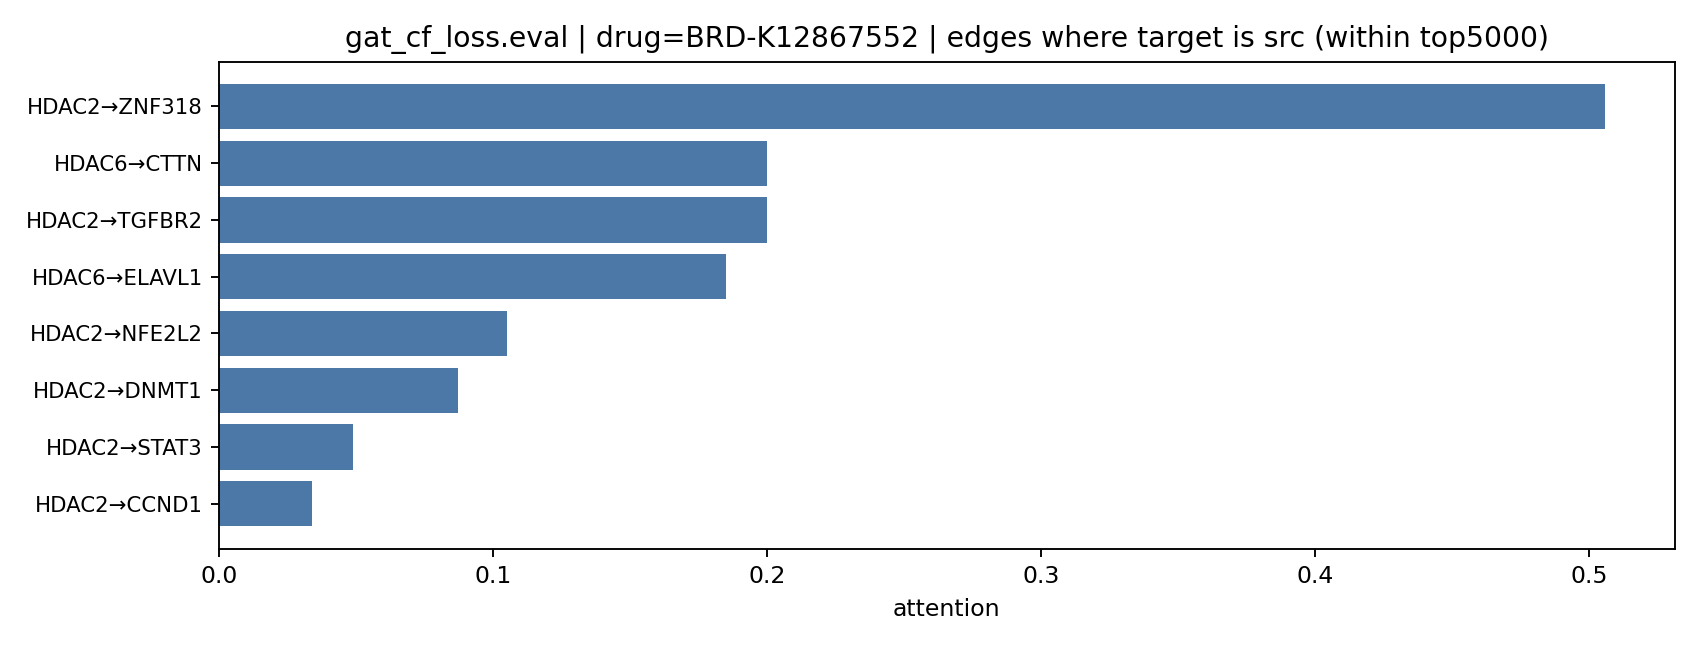

(      src_idx  dst_idx src_gene dst_gene  attention src_symbol dst_symbol
 0         896      947     4609     2184   0.884532        MYC        FAH
 1         896      444     4609     9709   0.881326        MYC    HERPUD1
 2         896      753     4609    26036   0.878820        MYC     ZNF451
 3         896       86     4609     2523   0.878000        MYC       FUT1
 4         896       14     4609     2356   0.876484        MYC       FPGS
 ...       ...      ...      ...      ...        ...        ...        ...
 1623      909      587     3329      581   0.017126      HSPD1        BAX
 1624      622      587     8996      581   0.017040       NOL3        BAX
 1625      525      644     7319     5111   0.016811      UBE2A       PCNA
 1626       70      644       25     5111   0.016604       ABL1       PCNA
 1627       70      587       25      581   0.016406       ABL1        BAX
 
 [1628 rows x 7 columns],
 '/Users/liuxi/Desktop/RFA_GNN/tmp/gat_cf_loss.fig/gat_cf_loss.eval_BRD-

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

target_src_top_k = 5000

gene_info_path = os.path.join(ROOT, "data", "GSE92742_Broad_LINCS_gene_info.txt")
gi = pd.read_csv(gene_info_path, sep="\t")
entrez2symbol_local = dict(zip(gi["pr_gene_id"].astype(str), gi["pr_gene_symbol"].astype(str)))

def _symbol_from_entrez(entrez_str):
    e = str(entrez_str)
    s = entrez2symbol_local.get(e)
    if s is None or str(s) == "nan":
        return e
    return str(s)

def show_target_as_src_edges(run, drug_id, top_k=200, layer=-1, out_path=None):
    df = pef.export_attention_top_edges_csv(
        run,
        out_path=os.path.join(out_fig_dir, f"{tag}_tmp_{str(drug_id)}_top_edges.csv"),
        top_k=int(top_k),
        layer=int(layer),
        group=str(drug_id),
    )
    df = df.copy()
    df["src_symbol"] = df["src_gene"].astype(str).map(_symbol_from_entrez)
    df["dst_symbol"] = df["dst_gene"].astype(str).map(_symbol_from_entrez)

    targets = _drug_target_node_indices(str(drug_id))
    target_syms = [_node_label(int(t)) for t in targets]
    print("drug=", drug_id, "targets=", target_syms)
    if len(targets) == 0:
        print("no targets for drug")
        return df, None

    df_hit = df[df["src_symbol"].isin(set(target_syms))].sort_values("attention", ascending=False)
    display(df_hit[["src_symbol", "dst_symbol", "attention"]])

    if len(df_hit) == 0:
        print("no top edges where target appears as src")
        return df, None

    plt.figure(figsize=(10.0, max(3.8, 0.32 * len(df_hit))), dpi=170)
    labels = [f"{r.src_symbol}→{r.dst_symbol}" for r in df_hit.itertuples(index=False)]
    vals = df_hit["attention"].astype(float).to_numpy()
    y = np.arange(len(vals))
    plt.barh(y, vals, color="#4C78A8")
    plt.yticks(y, labels, fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("attention")
    plt.title(f"{tag} | drug={drug_id} | edges where target is src (within top{int(top_k)})")
    plt.tight_layout()
    if out_path is None:
        out_path = os.path.join(out_fig_dir, f"{tag}_{str(drug_id)}_target_as_src_edges_top{int(top_k)}.png")
    plt.savefig(out_path)
    plt.close()
    display(Image(filename=out_path))
    return df, out_path

show_target_as_src_edges(run, best_drug, top_k=target_src_top_k, layer=-1)


In [ ]:
import numpy as np
import pandas as pd

layer = -1
top_k_src = 5
edges_per_src = 30
eps = 0.05

att = run.get("attention", {})
edge_index = np.asarray(att.get("edge_index"), dtype=int)
src_all = edge_index[0]
dst_all = edge_index[1]
non_self = src_all != dst_all
src_ns = src_all[non_self]
dst_ns = dst_all[non_self]

genes_entrez = np.asarray(run.get("target_genes"), dtype=str)
n = int(np.max(edge_index)) + 1 if edge_index.size else int(len(genes_entrez))
if len(genes_entrez) != n:
    genes_entrez = np.asarray([str(i) for i in range(n)], dtype=str)

gene_info_path = os.path.join(ROOT, "data", "GSE92742_Broad_LINCS_gene_info.txt")
gi = pd.read_csv(gene_info_path, sep="\t")
entrez2symbol_local = dict(zip(gi["pr_gene_id"].astype(str), gi["pr_gene_symbol"].astype(str)))
symbols = np.asarray([entrez2symbol_local.get(str(e), str(e)) for e in genes_entrez.tolist()], dtype=str)

tf_edges_path = os.path.join(ROOT, "data", "omnipath", "omnipath_tf_regulons.csv")
ppi_edges_path = os.path.join(ROOT, "data", "omnipath", "omnipath_interactions.csv")
df_tf_edges = pd.read_csv(tf_edges_path)
df_ppi_edges = pd.read_csv(ppi_edges_path)
df_edge_effect = pd.concat([df_tf_edges, df_ppi_edges], axis=0, ignore_index=True)
df_edge_effect["source_genesymbol"] = df_edge_effect["source_genesymbol"].astype(str).str.upper().str.strip()
df_edge_effect["target_genesymbol"] = df_edge_effect["target_genesymbol"].astype(str).str.upper().str.strip()

stim_cols = [c for c in ["consensus_stimulation", "is_stimulation"] if c in df_edge_effect.columns]
inh_cols = [c for c in ["consensus_inhibition", "is_inhibition"] if c in df_edge_effect.columns]
if len(stim_cols) == 0:
    df_edge_effect["_stim"] = False
else:
    df_edge_effect["_stim"] = df_edge_effect[stim_cols].fillna(False).astype(bool).any(axis=1)
if len(inh_cols) == 0:
    df_edge_effect["_inh"] = False
else:
    df_edge_effect["_inh"] = df_edge_effect[inh_cols].fillna(False).astype(bool).any(axis=1)

g = df_edge_effect.groupby(["source_genesymbol", "target_genesymbol"], as_index=False)[["_stim", "_inh"]].any()
effect_map = {}
ss = g["source_genesymbol"].astype(str).tolist()
tt = g["target_genesymbol"].astype(str).tolist()
st = g["_stim"].astype(bool).tolist()
ih = g["_inh"].astype(bool).tolist()
for s, t, stim, inh in zip(ss, tt, st, ih):
    if stim and not inh:
        eff = "+"
    elif inh and not stim:
        eff = "-"
    elif stim and inh:
        eff = "±"
    else:
        eff = "?"
    effect_map[(str(s), str(t))] = eff

def _pred_sign_for_drug(drug_id):
    drug_ids_all = np.asarray(run.get("drug_ids"), dtype=str)
    y_pred_all = np.asarray(run.get("y_pred"), dtype=np.float32)
    m = drug_ids_all == str(drug_id)
    if not bool(np.any(m)):
        return np.zeros((n,), dtype=np.int8)
    mu = np.mean(y_pred_all[m], axis=0)
    s = np.zeros_like(mu, dtype=np.int8)
    s[mu > float(eps)] = 1
    s[mu < -float(eps)] = -1
    return s

def _edge_effect_for_idx(u, v):
    su = str(symbols[int(u)]).upper().strip()
    sv = str(symbols[int(v)]).upper().strip()
    return effect_map.get((su, sv), "?")

def drug_attention_diagnostics(drug_id, top_k_src=5, edges_per_src=30):
    group_means = att.get("group_attention_edge_mean", {})
    if str(drug_id) not in group_means:
        return None
    alpha = np.asarray(group_means[str(drug_id)], dtype=np.float64)[int(layer)]
    alpha = alpha[non_self]
    masses = np.bincount(src_ns.astype(int), weights=alpha.astype(np.float64), minlength=n)
    total_mass = float(np.sum(masses))
    order = np.argsort(-masses)
    top_src = order[: int(top_k_src)]
    top_share = float(np.sum(masses[top_src]) / total_mass) if total_mass > 0 else 0.0

    pred_sign = _pred_sign_for_drug(drug_id)
    rows = []
    for sidx in top_src.tolist():
        sidx = int(sidx)
        m_s = src_ns.astype(int) == sidx
        if not bool(np.any(m_s)):
            rows.append({"src": str(symbols[sidx]), "mass": float(masses[sidx]), "share": float(masses[sidx] / total_mass) if total_mass > 0 else 0.0, "consistency": np.nan, "n_eval_edges": 0})
            continue
        a_s = alpha[m_s]
        d_s = dst_ns[m_s].astype(int)
        idx_e = np.argsort(-a_s)[: int(edges_per_src)]
        d_top = d_s[idx_e]
        ok = 0
        tot = 0
        for v in d_top.tolist():
            eff = _edge_effect_for_idx(sidx, int(v))
            ps = int(pred_sign[int(v)])
            if eff not in {"+", "-"}:
                continue
            if ps == 0:
                continue
            tot += 1
            if (eff == "+" and ps == 1) or (eff == "-" and ps == -1):
                ok += 1
        rows.append({"src": str(symbols[sidx]), "mass": float(masses[sidx]), "share": float(masses[sidx] / total_mass) if total_mass > 0 else 0.0, "consistency": float(ok / tot) if tot > 0 else np.nan, "n_eval_edges": int(tot)})

    return {"drug": str(drug_id), "total_mass": total_mass, "top_share": top_share, "src_rows": rows}

drugs = sorted(list((att.get("group_attention_edge_mean") or {}).keys()))
summ = []
for d in drugs:
    r = drug_attention_diagnostics(d, top_k_src=int(top_k_src), edges_per_src=int(edges_per_src))
    if r is None:
        continue
    rows = r["src_rows"]
    rec = {"drug": r["drug"], "top_src_mass_share": r["top_share"]}
    for i in range(min(3, len(rows))):
        rec[f"src{i+1}"] = rows[i]["src"]
        rec[f"src{i+1}_share"] = rows[i]["share"]
        rec[f"src{i+1}_consistency"] = rows[i]["consistency"]
        rec[f"src{i+1}_n"] = rows[i]["n_eval_edges"]
    summ.append(rec)

df_diag = pd.DataFrame(summ).sort_values("top_src_mass_share", ascending=False)
display(df_diag.head(20))

if "best_drug" in globals():
    r = drug_attention_diagnostics(best_drug, top_k_src=int(top_k_src), edges_per_src=int(edges_per_src))
    if r is not None:
        display(pd.DataFrame(r["src_rows"]))


,drug,top_src_mass_share,src1,src1_share,src1_consistency,src1_n,src2,src2_share,src2_consistency,src2_n,src3,src3_share,src3_consistency,src3_n
21,BRD-A63989068,0.355932,MYC,0.145460,0.413793,29,TP53,0.120317,0.571429,28,SRC,0.032910,0.391304,23
85,BRD-K88742110,0.348022,MYC,0.152589,0.357143,28,TP53,0.103822,0.714286,21,SRC,0.034471,0.409091,22
40,BRD-K12867552,0.344737,MYC,0.131851,0.433333,30,TP53,0.116080,0.703704,27,HIF1A,0.035960,0.666667,27
66,BRD-K69840642,0.334614,MYC,0.145043,0.433333,30,TP53,0.097898,0.800000,25,SRC,0.034979,0.333333,24
63,BRD-K61665160,0.325382,MYC,0.134821,0.275862,29,TP53,0.066324,0.692308,26,HIF1A,0.052490,0.520000,25
36,BRD-K07691486,0.317956,MYC,0.101162,0.192308,26,TP53,0.073371,0.666667,27,CDK1,0.065033,0.517241,29
43,BRD-K13662825,0.303670,MYC,0.091577,0.344828,29,TP53,0.075378,0.666667,27,CDK1,0.058518,0.464286,28
72,BRD-K79090631,0.300376,MYC,0.102835,0.346154,26,TP53,0.062414,0.629630,27,HIF1A,0.051851,0.478261,23
83,BRD-K86797399,0.280374,TP53,0.099377,0.714286,28,MYC,0.074145,0.250000,24,HIF1A,0.038049,0.576923,26
89,BRD-K92991072,0.277857,MYC,0.076345,0.296296,27,TP53,0.059240,0.760000,25,CDK1,0.056234,0.600000,25


,src,mass,share,consistency,n_eval_edges
0,MYC,38.719221,0.131851,0.433333,30
1,TP53,34.087959,0.116080,0.703704,27
2,HIF1A,10.559955,0.035960,0.666667,27
3,SRC,9.644957,0.032844,0.454545,22
4,AKT1,8.223133,0.028002,0.545455,22


In [ ]:
# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# from IPython.display import Image, display

# edge_index = np.asarray(run["attention"]["edge_index"], dtype=int)
# src_all = edge_index[0]
# dst_all = edge_index[1]

# print("CASE_GRAPH_VERSION=3")
# G_dir = nx.DiGraph()
# G_dir.add_nodes_from(range(int(np.max(edge_index)) + 1))
# G_dir.add_edges_from(list(zip(src_all.tolist(), dst_all.tolist())))
# G_und = G_dir.to_undirected(as_view=False)

# genes = np.asarray(run.get("target_genes"), dtype=str)
# entrez_to_idx = {str(g): int(i) for i, g in enumerate(genes.tolist())}

# gene_info_path = os.path.join(ROOT, "data", "GSE92742_Broad_LINCS_gene_info.txt")
# gi = pd.read_csv(gene_info_path, sep="\t")
# entrez2symbol = dict(zip(gi["pr_gene_id"].astype(str), gi["pr_gene_symbol"].astype(str)))
# symbol2entrez = dict(zip(gi["pr_gene_symbol"].astype(str), gi["pr_gene_id"].astype(str)))

# compound_targets_path = os.path.join(ROOT, "data", "compound_targets.txt")
# df_targets = pd.read_csv(compound_targets_path, sep="\t", dtype=str)

# def _drug_target_node_indices(pert_id):
#     m = df_targets["pert_id"].astype(str) == str(pert_id)
#     if not bool(np.any(m)):
#         return []
#     target_strs = df_targets.loc[m, "target"].astype(str).tolist()
#     symbols = []
#     for s in target_strs:
#         if s.strip() == "" or s.strip() == '""':
#             continue
#         symbols.extend([t.strip() for t in s.split(",") if t.strip() != ""])
#     if len(symbols) == 0:
#         return []
#     symbols = list(dict.fromkeys(symbols))
#     entrez = []
#     for sym in symbols:
#         sym = str(sym)
#         if sym in symbol2entrez:
#             entrez.append(str(symbol2entrez[sym]))
#     idx = []
#     for e in entrez:
#         if e in entrez_to_idx:
#             idx.append(int(entrez_to_idx[e]))
#     return sorted(set(idx))

# def _node_label(i):
#     e = str(genes[int(i)])
#     s = entrez2symbol.get(e)
#     if s is None or str(s) == "nan":
#         return e
#     return str(s)

# def plot_targets_to_top_edges(df_top, pert_id, out_path, max_hops=6, use_directed_paths=False, plot_top_k=15, show_context=False):
#     df_top = df_top.copy()
#     df_plot = df_top.sort_values("attention", ascending=False).head(int(plot_top_k))
#     top_edges = set(zip(df_plot["src_idx"].astype(int).tolist(), df_plot["dst_idx"].astype(int).tolist()))
#     endpoints = sorted(set([u for u, v in top_edges] + [v for u, v in top_edges]))
#     targets = _drug_target_node_indices(pert_id)
#     target_labels = [_node_label(t) for t in targets]
#     print("drug=", pert_id, "targets(n)=", len(targets), "targets=", target_labels[:25])

#     path_edges = set()
#     path_nodes = set()
#     reachable = 0
#     unreachable = []
#     G_path = G_dir if bool(use_directed_paths) else G_und
#     for e in endpoints:
#         if len(targets) == 0:
#             break
#         try:
#             _, path = nx.multi_source_dijkstra(G_path, sources=targets, target=int(e), weight=None, cutoff=int(max_hops))
#         except Exception:
#             path = None
#         if path is None or len(path) < 2:
#             unreachable.append(int(e))
#             continue
#         reachable += 1
#         path_nodes.update([int(x) for x in path])
#         for a, b in zip(path[:-1], path[1:]):
#             path_edges.add((int(a), int(b)))

#     print("reachable_endpoints=", reachable, "/", len(endpoints), "within_hops=", int(max_hops))
#     if len(unreachable) > 0:
#         print("unreachable_endpoints(sample)=", [_node_label(u) for u in unreachable[:20]])

#     nodes = set(targets) | set(endpoints) | set(path_nodes)
#     for a, b in list(path_edges) + list(top_edges):
#         nodes.add(int(a))
#         nodes.add(int(b))
#     H = G_dir.subgraph(nodes).copy()

#     if len(targets) > 0:
#         dist_map = nx.multi_source_dijkstra_path_length(G_path, sources=targets, weight=None, cutoff=int(max_hops))
#     else:
#         dist_map = {}
#     maxd = max(dist_map.values()) if len(dist_map) > 0 else 0
#     layers = {}
#     for n in H.nodes():
#         d = dist_map.get(int(n), maxd + 1)
#         layers.setdefault(int(d), []).append(int(n))
#     for d in layers:
#         layers[d].sort(key=lambda x: _node_label(x))
#     pos = {}
#     for d, ns in sorted(layers.items(), key=lambda kv: kv[0]):
#         m = len(ns)
#         ys = np.linspace(-(m - 1) / 2.0, (m - 1) / 2.0, m) if m > 1 else np.array([0.0])
#         for n, y in zip(ns, ys):
#             pos[int(n)] = (float(d) * 2.2, float(y) * 1.4)

#     plt.figure(figsize=(15.0, 9.0), dpi=160)

#     if bool(show_context):
#         ctx_edges = [e for e in H.edges() if e not in top_edges and e not in path_edges]
#         nx.draw_networkx_edges(H, pos, edgelist=ctx_edges, width=0.6, alpha=0.05, edge_color="#A0A0A0", arrows=False)
#     if len(path_edges) > 0:
#         nx.draw_networkx_edges(H, pos, edgelist=list(path_edges), width=3.2, alpha=0.95, edge_color="#1F77B4", arrows=False)
#     nx.draw_networkx_edges(H, pos, edgelist=list(top_edges), width=3.8, alpha=0.98, edge_color="#D62728", arrows=False)

#     other_nodes = [n for n in H.nodes() if n not in set(targets) and n not in set(endpoints) and n not in path_nodes]
#     nx.draw_networkx_nodes(H, pos, nodelist=other_nodes, node_size=18, node_color="#BDBDBD", alpha=0.18)
#     if len(path_nodes) > 0:
#         mid_nodes = [n for n in path_nodes if n not in set(targets) and n not in set(endpoints)]
#         nx.draw_networkx_nodes(H, pos, nodelist=mid_nodes, node_size=110, node_color="#AEC7E8", alpha=0.98)
#     nx.draw_networkx_nodes(H, pos, nodelist=endpoints, node_size=150, node_color="#FF7F0E", alpha=0.98)
#     if len(targets) > 0:
#         nx.draw_networkx_nodes(H, pos, nodelist=targets, node_size=210, node_color="#2CA02C", alpha=0.98)

#     label_nodes = set(targets) | set(endpoints) | set(path_nodes)
#     labels = {int(n): _node_label(n) for n in label_nodes}
#     nx.draw_networkx_labels(
#         H,
#         pos,
#         labels=labels,
#         font_size=9,
#         font_color="#111111",
#         bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2),
#     )

#     mode_str = "directed" if bool(use_directed_paths) else "undirected"
#     plt.title(f"{tag} | drug={pert_id} | targets(green) → paths(blue,{mode_str}) → top edges(red)")
#     plt.axis("off")
#     plt.tight_layout()
#     plt.savefig(out_path)
#     plt.close()
#     display(Image(filename=out_path))

# p1 = os.path.join(out_fig_dir, f"{tag}_best_drug_targets_to_top_edges.png")
# p2 = os.path.join(out_fig_dir, f"{tag}_worst_drug_targets_to_top_edges.png")

# plot_targets_to_top_edges(df_best, best_drug, out_path=p1, max_hops=6, use_directed_paths=False, plot_top_k=15, show_context=False)
# plot_targets_to_top_edges(df_worst, worst_drug, out_path=p2, max_hops=6, use_directed_paths=False, plot_top_k=15, show_context=False)


In [ ]:
edge_index = att["edge_index"]
src = edge_index[0].astype(int)
dst = edge_index[1].astype(int)
non_self = src != dst

A_best = np.asarray(att["group_attention_edge_mean"][best_drug], dtype=float)[-1]
A_worst = np.asarray(att["group_attention_edge_mean"][worst_drug], dtype=float)[-1]

n_nodes = int(np.max(edge_index)) + 1
s_best = np.zeros((n_nodes,), dtype=float)
s_worst = np.zeros((n_nodes,), dtype=float)
np.add.at(s_best, dst[non_self], A_best[non_self])
np.add.at(s_worst, dst[non_self], A_worst[non_self])

genes = np.asarray(run.get("target_genes"), dtype=str)
df = pd.DataFrame({"entrez": genes, "best": s_best, "worst": s_worst})
df["diff_best_minus_worst"] = df["best"] - df["worst"]
df = df.sort_values("diff_best_minus_worst", ascending=False).head(25)
df["symbol"] = df["entrez"].astype(str).map(entrez2symbol)
display(df[["symbol", "entrez", "best", "worst", "diff_best_minus_worst"]])


,symbol,entrez,best,worst,diff_best_minus_worst
311,CCNB2,9133,0.785374,0.384465,0.400908
44,MYCBP2,23077,0.821839,0.425299,0.396540
20,UBE2C,11065,0.861894,0.469779,0.392115
678,IFRD2,7866,0.858413,0.467292,0.391121
154,CRYZ,1429,0.796907,0.408513,0.388394
86,FUT1,2523,0.878000,0.501008,0.376993
521,PSMG1,8624,0.857731,0.490206,0.367525
693,SESN1,27244,0.805230,0.445474,0.359755
444,HERPUD1,9709,0.881326,0.531908,0.349419
947,FAH,2184,0.884532,0.541183,0.343349
